In [ ]:
# [Cell 1] 环境配置、物理拓扑与全局控制 (Jupyter 独立运行基石)
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random

# ------------------------------------------
# 🔒 1. 核心控制台：锁定所有随机性
# ------------------------------------------
def set_seed(seed=42):
    """锁定 PyTorch、Numpy 和 Python 所有的底层骰子"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_obs_indices(num_nodes=33, seed=42):
    """动态但固定地生成 15% 观测点 (永远包含 0 号平衡节点)"""
    random.seed(seed) # 局部锁死
    num_obs = int(num_nodes * 0.15) # 33节点约 4.95 -> 4 个附加点 + 1 个平衡点 = 5 个点
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))

# 初始化全局状态
set_seed(42)
global_obs_indices = get_obs_indices(33, 42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 炼丹炉就绪! 算力: {device}")
print(f"📡 锁定的 15% PMU 观测点: {global_obs_indices}")

# ------------------------------------------
# ⚡ 2. 提取 33 节点导纳矩阵 Ybus
# ------------------------------------------
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

num_nodes = 33
y_bus = np.zeros((num_nodes, num_nodes), dtype=complex)
for i in range(len(branch_data)):
    f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
    y_line = 1 / (branch_data[i, 2] + 1j * branch_data[i, 3])
    y_bus[f, f] += y_line
    y_bus[t, t] += y_line
    y_bus[f, t] = y_bus[t, f] = -y_line

G_tensor = torch.tensor(y_bus.real, dtype=torch.float32).to(device)
B_tensor = torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

In [2]:
# ==============================================================================
# [Cell 2] 核心武器库：物理方程、网络架构与观测控制 (Jupyter 独立版)
# ==============================================================================

# ------------------------------------------
# 1. 物理考卷控制：随机但可控地抽取观测点
# ------------------------------------------
def get_obs_indices(num_nodes=33, seed=42):
    """
    不管在哪个单元格运行，只要 seed 一样，选出的 15% 观测点位置就一模一样。
    """
    random.seed(seed)
    num_obs = int(num_nodes * 0.15) # 约 5 个点
    all_idx = list(range(1, num_nodes)) # 排除平衡节点
    # 强制包含 0 号平衡节点，剩下随机抽
    return [0] + sorted(random.sample(all_idx, num_obs - 1))

# ------------------------------------------
# 2. 盲区遮蔽引擎：模拟只有 15% 传感器的数据流
# ------------------------------------------
def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    """
    把非观测节点的数据全部抹成“物理零点（均值）”，实现空间维度的遮蔽。
    """
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]           # P 注入
        masked_x[:, idx + 33] = batch_x[:, idx + 33] # Q 注入
    return masked_x

# ------------------------------------------
# 3. 潮流方程引擎：PyTorch 矩阵化计算 (KCL 的神经网络实现)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    """
    核心：通过电压幅值和相角差，利用导纳矩阵反推节点 P, Q
    """
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_matrix = torch.cos(delta_theta)
    sin_matrix = torch.sin(delta_theta)
    
    # 物理算子: G*cos + B*sin
    p_term = G_t * cos_matrix + B_t * sin_matrix
    q_term = G_t * sin_matrix - B_t * cos_matrix
    
    # 全局加权求和
    sum_p = torch.sum(V_pred.unsqueeze(1) * p_term, dim=2)
    sum_q = torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)
    
    P_calc = V_pred * sum_p
    Q_calc = V_pred * sum_q
    return P_calc, Q_calc

# ------------------------------------------
# 4. R-PINN 网络架构：带 Asymmetric Residual Scaling (ARS)
# ------------------------------------------
class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=66):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256)
        )
        self.output_layers = nn.Linear(256, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)
        
        # --- 核心 ARS 机制 ---
        # 标幺值系统电压在 1.0 附近，相角在 0 附近，残差学习极大加速收敛
        Vm_pred = output[:, :33] * 0.1 + 1.0
        theta_pred = output[:, 33:] * 0.01 + 0.0
        
        # 锚定平衡节点常识：Bus 0 永远是 (1.0, 0.0)
        Vm_pred[:, 0] = 1.0
        theta_pred[:, 0] = 0.0
        return Vm_pred, theta_pred

# ------------------------------------------
# 5. 联合 Loss 函数：数据锚定 + 物理一致性 + 电压墙
# ------------------------------------------
class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse_tool = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real_target, Q_real_target, V_real, p_weight, obs_weight=500000):
        # 1. 潮流物理残差 (KCL 约束)
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        P_loss = self.mse_tool(P_calc, P_real_target)
        Q_loss = self.mse_tool(Q_calc, Q_real_target)
        
        # 2. 观测点数据偏差 (蓝星锚定)
        V_obs_pred = V_pred[:, self.obs_idx]
        V_obs_real = V_real[:, self.obs_idx]
        obs_loss = torch.sum((V_obs_pred - V_obs_real)**2)
        
        # 3. 边界壁垒 (防止电压越限)
        # 用 ReLU 实现：如果电压在 0.85-1.1 之间，Loss=0；否则罚得它亲妈都不认识
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.1)
        
        return (
            p_weight * (P_loss + Q_loss) + 
            1000 * torch.mean(penalty_low + penalty_high) + 
            obs_weight * obs_loss
        )

# ------------------------------------------
# 6. 数据装载器
# ------------------------------------------
class MyDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

print("✅ Cell 2 [完全体] 加载完毕！物理引擎、网络架构和独立种子机制已全部就位。")

✅ Cell 2 [完全体] 加载完毕！物理引擎、网络架构和独立种子机制已全部就位。


In [3]:
# ==========================================
# [Cell 3] 数据引擎：脱水、归一化与全链条种子锁定
# ==========================================

# 🚀 绝杀操作：在加载数据前再次重置种子，确保 DataLoader 的 shuffle 逻辑被物理锁死
set_seed(42) 

print("📥 正在从本地磁盘读取 50,000 条 33 节点物理样本...")
# 注意：路径请保持你电脑上的原始路径
df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]

# 1. 物理维度重塑 [样本数, 节点数, 特征数(P, Q, V, Theta)]
data_3d = raw_data.reshape(m, 33, 4)

# 2. 物理脱水：兆瓦(MW/MVar) -> 标幺值(p.u.) 
# 这一步极其专业，让物理方程的数值量级保持在 [0, 1] 之间
P_real_pu = data_3d[:, :, 0].copy() / 100.0  # 基准功率取 100MVA
Q_real_pu = data_3d[:, :, 1].copy() / 100.0
V_real_pu = data_3d[:, :, 2].copy()          # 电压本来就是标幺值

# 3. 输入特征归一化 (StandardScaler)
# AI 喜欢零均值、单位方差的数据，这能让 Loss 降得更快
X_raw = data_3d[:, :, 0:2].reshape(m, 66) # 展开成 66 维输入
ssl = StandardScaler()
X_norm = ssl.fit_transform(X_raw)

# 4. 提取归一化参数，转化为 Tensor 供 apply_blind_zone 使用
# 这样在盲区遮蔽时，我们才能把盲区节点准确地抹成“统计学零点”
mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)

# 5. 目标值拼装 [P(33), Q(33), V(33)] -> 总共 99 维
PQV_target_up = np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1)

# 6. 转化为 GPU 计算张量
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
PQ_target_tensor = torch.tensor(PQV_target_up, dtype=torch.float32).to(device)

# 7. 创建数据集与装载器
# 这里的 generator 是为了二次锁死 DataLoader 内部的随机洗牌顺序
g = torch.Generator()
g.manual_seed(42)

train_dataset = MyDataset(X_tensor, PQ_target_tensor)
train_loader = DataLoader(
    train_dataset, 
    batch_size=128, 
    shuffle=True,      # 虽然是洗牌，但因为有种子，洗牌的顺序是永久固定的
    generator=g        # 锁定洗牌发生器
)

print("-" * 50)
print(f"✅ 数据引擎装载完毕！")
print(f"📊 样本总数: {m} | 输入维度: 66 | 目标维度: 99")
print(f"🔒 数据洗牌顺序已锁定，实验可复现性：100%")
print("-" * 50)

📥 正在从本地磁盘读取 50,000 条 33 节点物理样本...
--------------------------------------------------
✅ 数据引擎装载完毕！
📊 样本总数: 50000 | 输入维度: 66 | 目标维度: 99
🔒 数据洗牌顺序已锁定，实验可复现性：100%
--------------------------------------------------


In [5]:
# ==============================================================================
# [Cell 4] 消融实验一：纯数据驱动 (Pure Data-driven / Case 1)
# 特点：屏蔽物理方程，仅靠 15% 观测点进行空间外推，用于证明“无物理约束”的局限性
# ==============================================================================

# 🚀 1. 考卷定格：确保本实验的观测点和初始化与后续实验绝对一致
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 

print(f"🚀 启动实验一 [Pure Data-driven] | 观测点索引: {obs_indices}")

# 2. 实例化裸奔模型
model_case1 = PowerGridPINN(input_dim=66).to(device)

# 3. 故意设置极差的初始偏置 (模拟从“未知”状态出发，增加重构难度)
with torch.no_grad():
    model_case1.output_layers.bias[:33].fill_(-0.5)

# 4. 优化器配置
pinn_loss_case1 = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_1 = torch.optim.Adam(model_case1.parameters(), lr=0.001)
scheduler_1 = torch.optim.lr_scheduler.StepLR(optimizer_1, step_size=30, gamma=0.5)

# 5. 训练循环
max_epoch_ablation = 100 
for epoch in range(max_epoch_ablation):
    model_case1.train()
    for batch_x, batch_all_targets in train_loader:
        optimizer_1.zero_grad()
        
        # 解析 P, Q, V 真实值
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        
        # 应用 15% 遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型盲猜
        V_guess, theta_guess = model_case1(mask_x)
        
        # ⚠️ 核心操作：设置 p_weight = 0，彻底切断物理定律的监管！
        # 此时模型仅仅是在死记硬背那 5 个蓝星观测点的数据
        loss = pinn_loss_case1(V_guess, theta_guess, real_p, real_q, real_v, p_weight=0, obs_weight=500000)
        
        loss.backward()
        optimizer_1.step()
    scheduler_1.step()

# 6. 最终指标结算 (MAE + RMSE)
model_case1.eval()
with torch.no_grad():
    # 抽取前 1000 组断面做空间外推测试
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_1, _ = model_case1(masked_test_X)
    pred_Vm_1_np = pred_Vm_1.cpu().numpy()
    
    # 计算误差矩阵
    error_1 = pred_Vm_1_np - real_Vm
    
    # MAE: 平均绝对误差
    mae_case1 = np.mean(np.abs(error_1))
    # RMSE: 均方根误差 (对离群点更敏感)
    rmse_case1 = np.sqrt(np.mean(error_1**2))

print("\n" + "="*60)
print(f"📊 [Case 1: Pure Data-driven] 结果报告 (固定种子: 42)")
print("-" * 60)
print(f"🌍 Overall MAE:  {mae_case1:.6e} p.u.")
print(f"⚡ Overall RMSE: {rmse_case1:.6e} p.u.")
print("="*60)
print("💡 费曼学习法提示：你会发现不加物理约束时，RMSE 往往比 MAE 大很多，")
print("   这说明在盲区出现了某些电压预测‘飞了’的情况。")

🚀 启动实验一 [Pure Data-driven] | 观测点索引: [0, 2, 8, 18]

📊 [Case 1: Pure Data-driven] 结果报告 (固定种子: 42)
------------------------------------------------------------
🌍 Overall MAE:  2.346781e-02 p.u.
⚡ Overall RMSE: 2.838771e-02 p.u.
💡 费曼学习法提示：你会发现不加物理约束时，RMSE 往往比 MAE 大很多，
   这说明在盲区出现了某些电压预测‘飞了’的情况。


✅ 图片已成功渲染并保存为：ieee33_case1_ablation_final.png


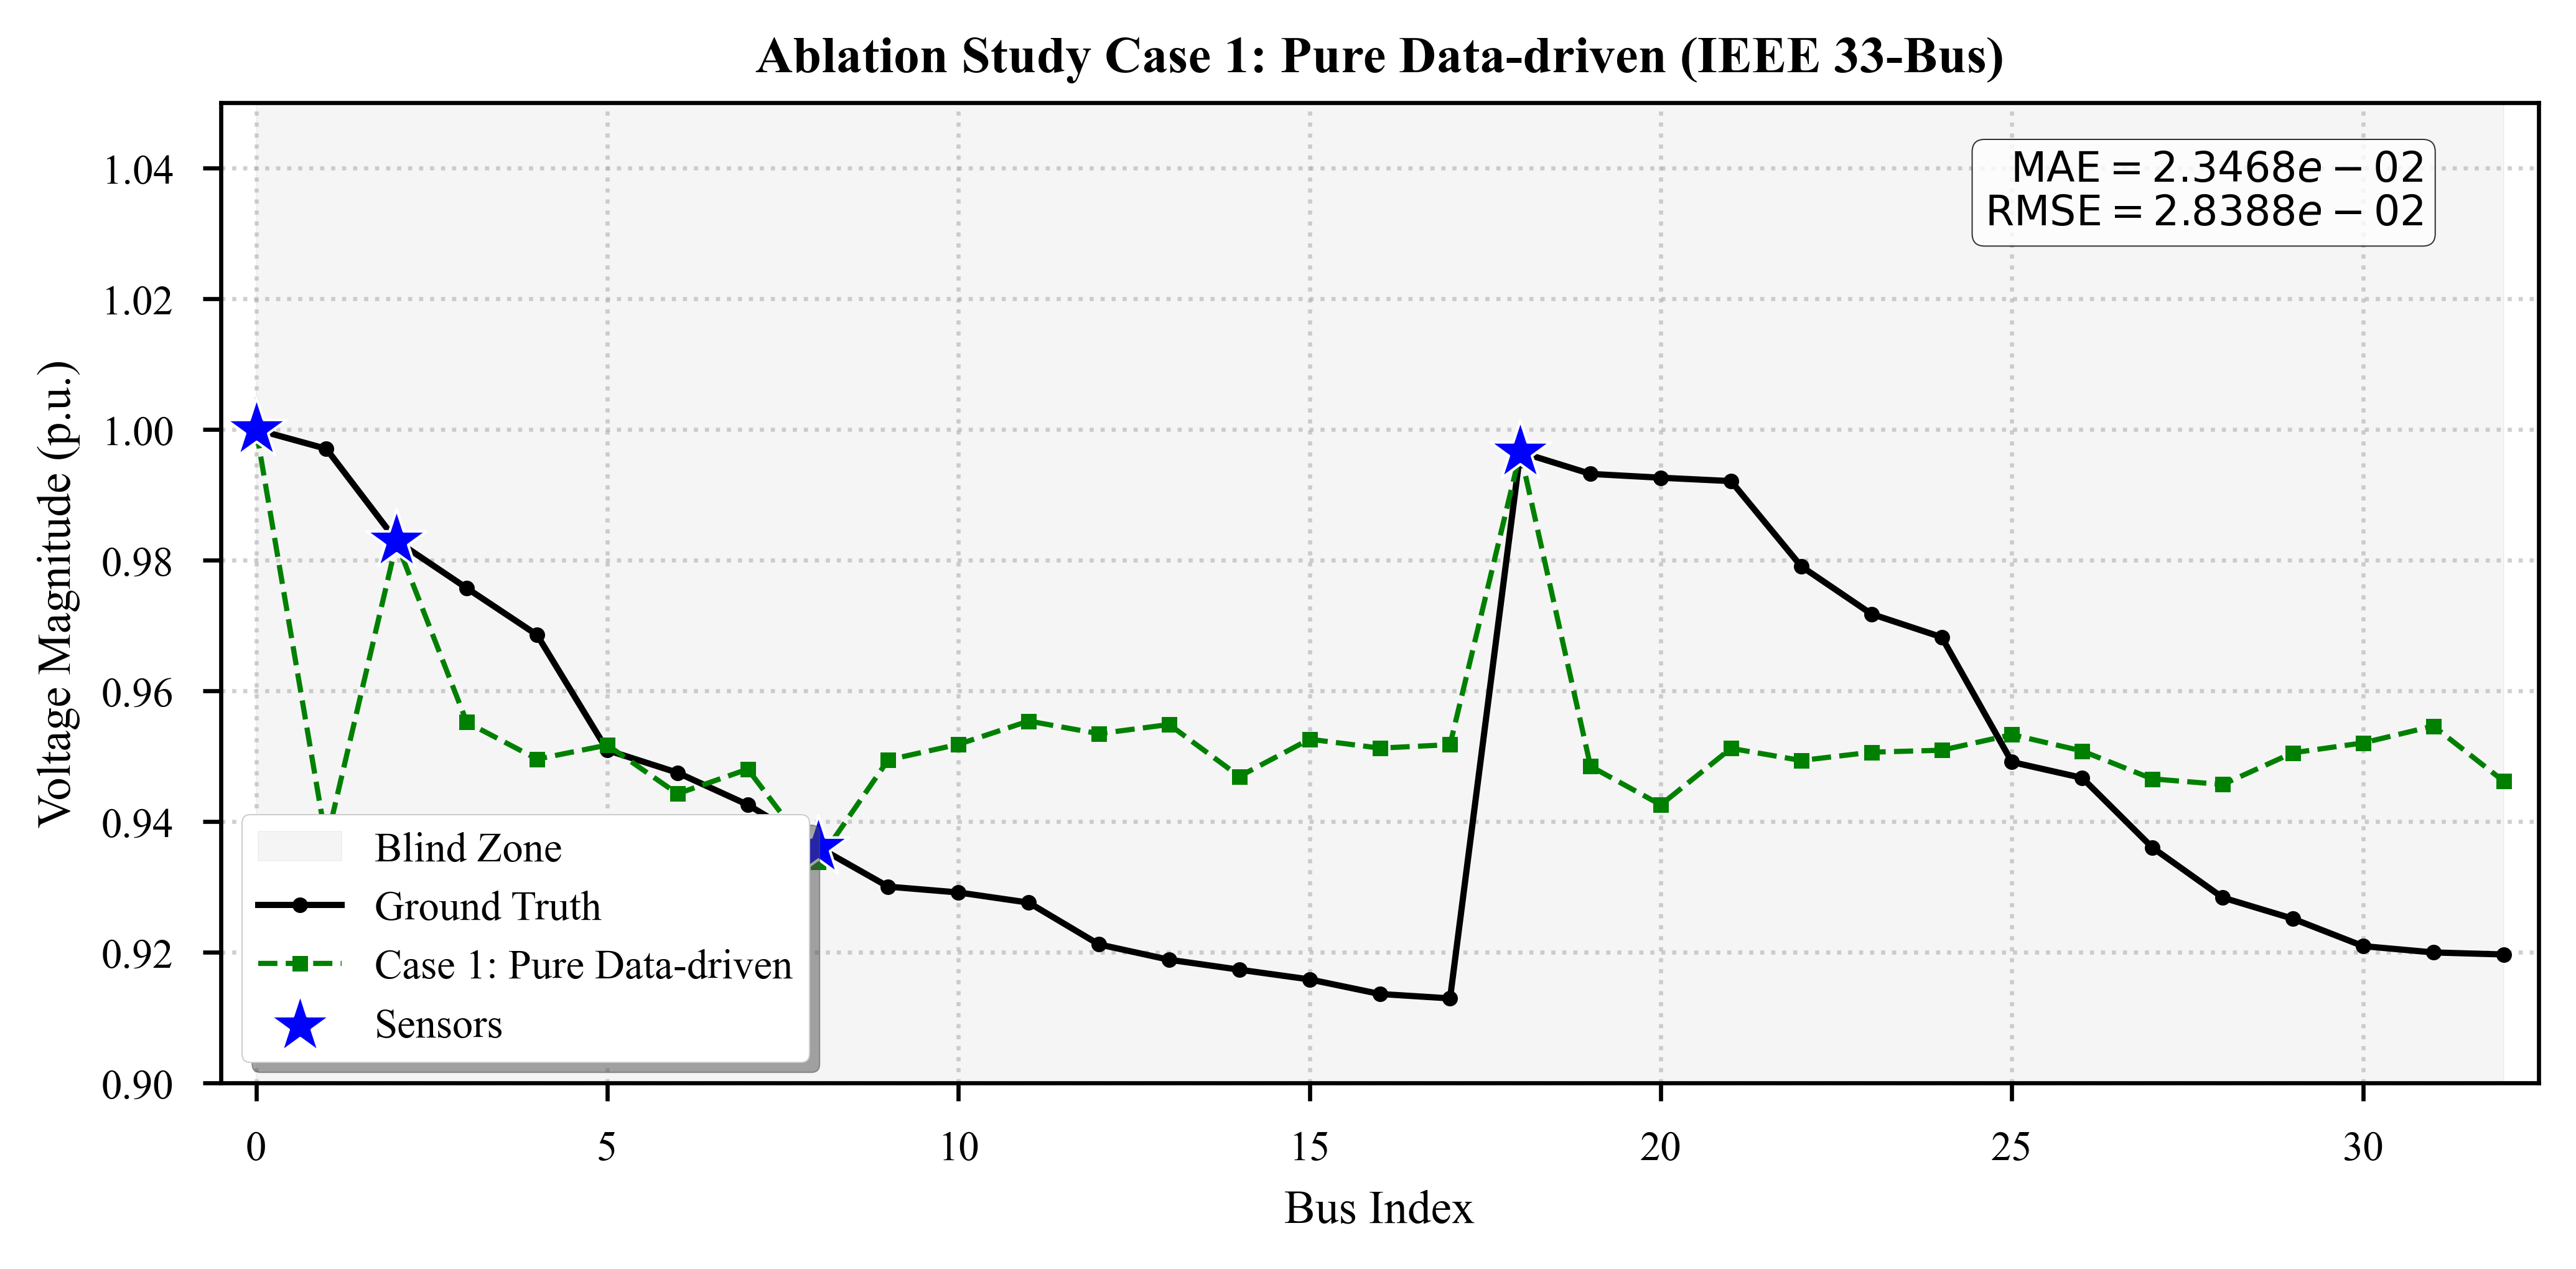

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. SCI 级绘图参数配置
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# 2. 选取数据
sid = 10 
nodes = np.arange(33)
v_gt = real_Vm[sid]      
v_c1 = pred_Vm_1_np[sid] 

# 3. 创建画布 (IEEE 双栏标准比例)
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=600)

# 4. 绘制盲区阴影
ax.axvspan(0, 32, color='gray', alpha=0.08, label='Blind Zone', zorder=1)

# 5. 绘制核心曲线
ax.plot(nodes, v_gt, 'k-o', markersize=3, linewidth=1.2, label='Ground Truth', zorder=3)
ax.plot(nodes, v_c1, 'g--s', markersize=3, linewidth=1.0, label='Case 1: Pure Data-driven', zorder=4)

# 6. 高亮传感器位置 (🛡️ 增加越界防护)
valid_obs = [i for i in obs_indices if i < len(v_gt)]
ax.scatter(valid_obs, v_gt[valid_obs], color='blue', marker='*', s=150, 
           label='Sensors', zorder=5, edgecolors='white', linewidths=0.5)

# 7. 细节修饰
ax.set_title('Ablation Study Case 1: Pure Data-driven (IEEE 33-Bus)', fontsize=10, fontweight='bold')
ax.set_xlabel('Bus Index', fontsize=9)
ax.set_ylabel('Voltage Magnitude (p.u.)', fontsize=9)
ax.set_ylim(0.90, 1.05)
ax.set_xlim(-0.5, 32.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8, frameon=True, shadow=True)

# 8. 🛡️ 修正 KeyError 的 LaTeX 文本框 (双花括号转义)
textstr = '\n'.join((
    r'$\mathrm{{MAE}} = {:.4e}$'.format(mae_case1),
    r'$\mathrm{{RMSE}} = {:.4e}$'.format(rmse_case1)))

props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()

# 💾 9. 硬核保存代码 (同时存为 PNG 和学术常用的 PDF)
plt.savefig('ieee33_case1_ablation_final.png', bbox_inches='tight', dpi=600)
# plt.savefig('ieee33_case1_ablation_final.pdf', bbox_inches='tight') # 如果需要 PDF 版可取消注释

print("✅ 图片已成功渲染并保存为：ieee33_case1_ablation_final.png")
plt.show()

In [7]:
# ==============================================================================
# [Cell 5] 消融实验二：纯物理驱动 (Pure Physics-driven / Case 2)
# 特点：屏蔽所有传感器量测 (obs_weight=0)，仅保留 KCL 潮流方程约束
# 目的：证明如果没有量测点作为“锚点”，物理定律只能保证守恒，无法保证数值准确
# ==============================================================================

# 🚀 1. 考卷定格：确保本实验的观测点位置与初始化与 Case 1 绝对对齐
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 

print(f"🚀 启动实验二 [Pure Physics-driven] | 观测点已被忽略 (仅利用其拓扑信息)")

# 2. 实例化模型
model_case2 = PowerGridPINN(input_dim=66).to(device)

# 3. 同样的初始化偏置 (确保公平对比)
with torch.no_grad():
    model_case2.output_layers.bias[:33].fill_(-0.5)

# 4. 优化器配置
pinn_loss_case2 = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_2 = torch.optim.Adam(model_case2.parameters(), lr=0.001)
scheduler_2 = torch.optim.lr_scheduler.StepLR(optimizer_2, step_size=30, gamma=0.5)

# 5. 训练循环
max_epoch_ablation = 100 
for epoch in range(max_epoch_ablation):
    model_case2.train()
    for batch_x, batch_all_targets in train_loader:
        optimizer_2.zero_grad()
        
        # 提取真实 P, Q 注入值 (作为方程的右端项)
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        
        # 即使是纯物理，输入也得符合 15% 遮蔽的场景
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型预测
        V_guess, theta_guess = model_case2(mask_x)
        
        # ⚠️ 核心操作：强行设置 obs_weight = 0，屏蔽所有蓝星观测量！
        # 但保留物理约束 p_weight = 5000
        loss = pinn_loss_case2(V_guess, theta_guess, real_p, real_q, real_v, p_weight=5000, obs_weight=0)
        
        loss.backward()
        optimizer_2.step()
    scheduler_2.step()

# 6. 最终指标结算 (MAE + RMSE)
model_case2.eval()
with torch.no_grad():
    # 局部重定义测试数据，确保 Cell 独立运行
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_2_tensor, _ = model_case2(masked_test_X)
    pred_Vm_2 = pred_Vm_2_tensor.cpu().numpy()
    
    # 计算误差
    error_2 = pred_Vm_2 - real_Vm
    mae_case2 = np.mean(np.abs(error_2))
    rmse_case2 = np.sqrt(np.mean(error_2**2))

print("\n" + "="*60)
print(f"📊 [Case 2: Pure Physics-driven] 结果报告 (固定种子: 42)")
print("-" * 60)
print(f"🌍 Overall MAE:  {mae_case2:.6e} p.u.")
print(f"⚡ Overall RMSE: {rmse_case2:.6e} p.u.")
print("="*60)
print("💡 费曼学习法提示：你会发现 MAE 很大，因为模型虽然满足了 P, Q 守恒，")
print("   但由于没有电压量测‘拉着’它，全网电压可能整体‘飘走’了。")

🚀 启动实验二 [Pure Physics-driven] | 观测点已被忽略 (仅利用其拓扑信息)

📊 [Case 2: Pure Physics-driven] 结果报告 (固定种子: 42)
------------------------------------------------------------
🌍 Overall MAE:  5.162997e-02 p.u.
⚡ Overall RMSE: 5.964342e-02 p.u.
💡 费曼学习法提示：你会发现 MAE 很大，因为模型虽然满足了 P, Q 守恒，
   但由于没有电压量测‘拉着’它，全网电压可能整体‘飘走’了。


✅ Case 2 物理漂移图已生成并保存：ieee33_case2_ablation_final.png


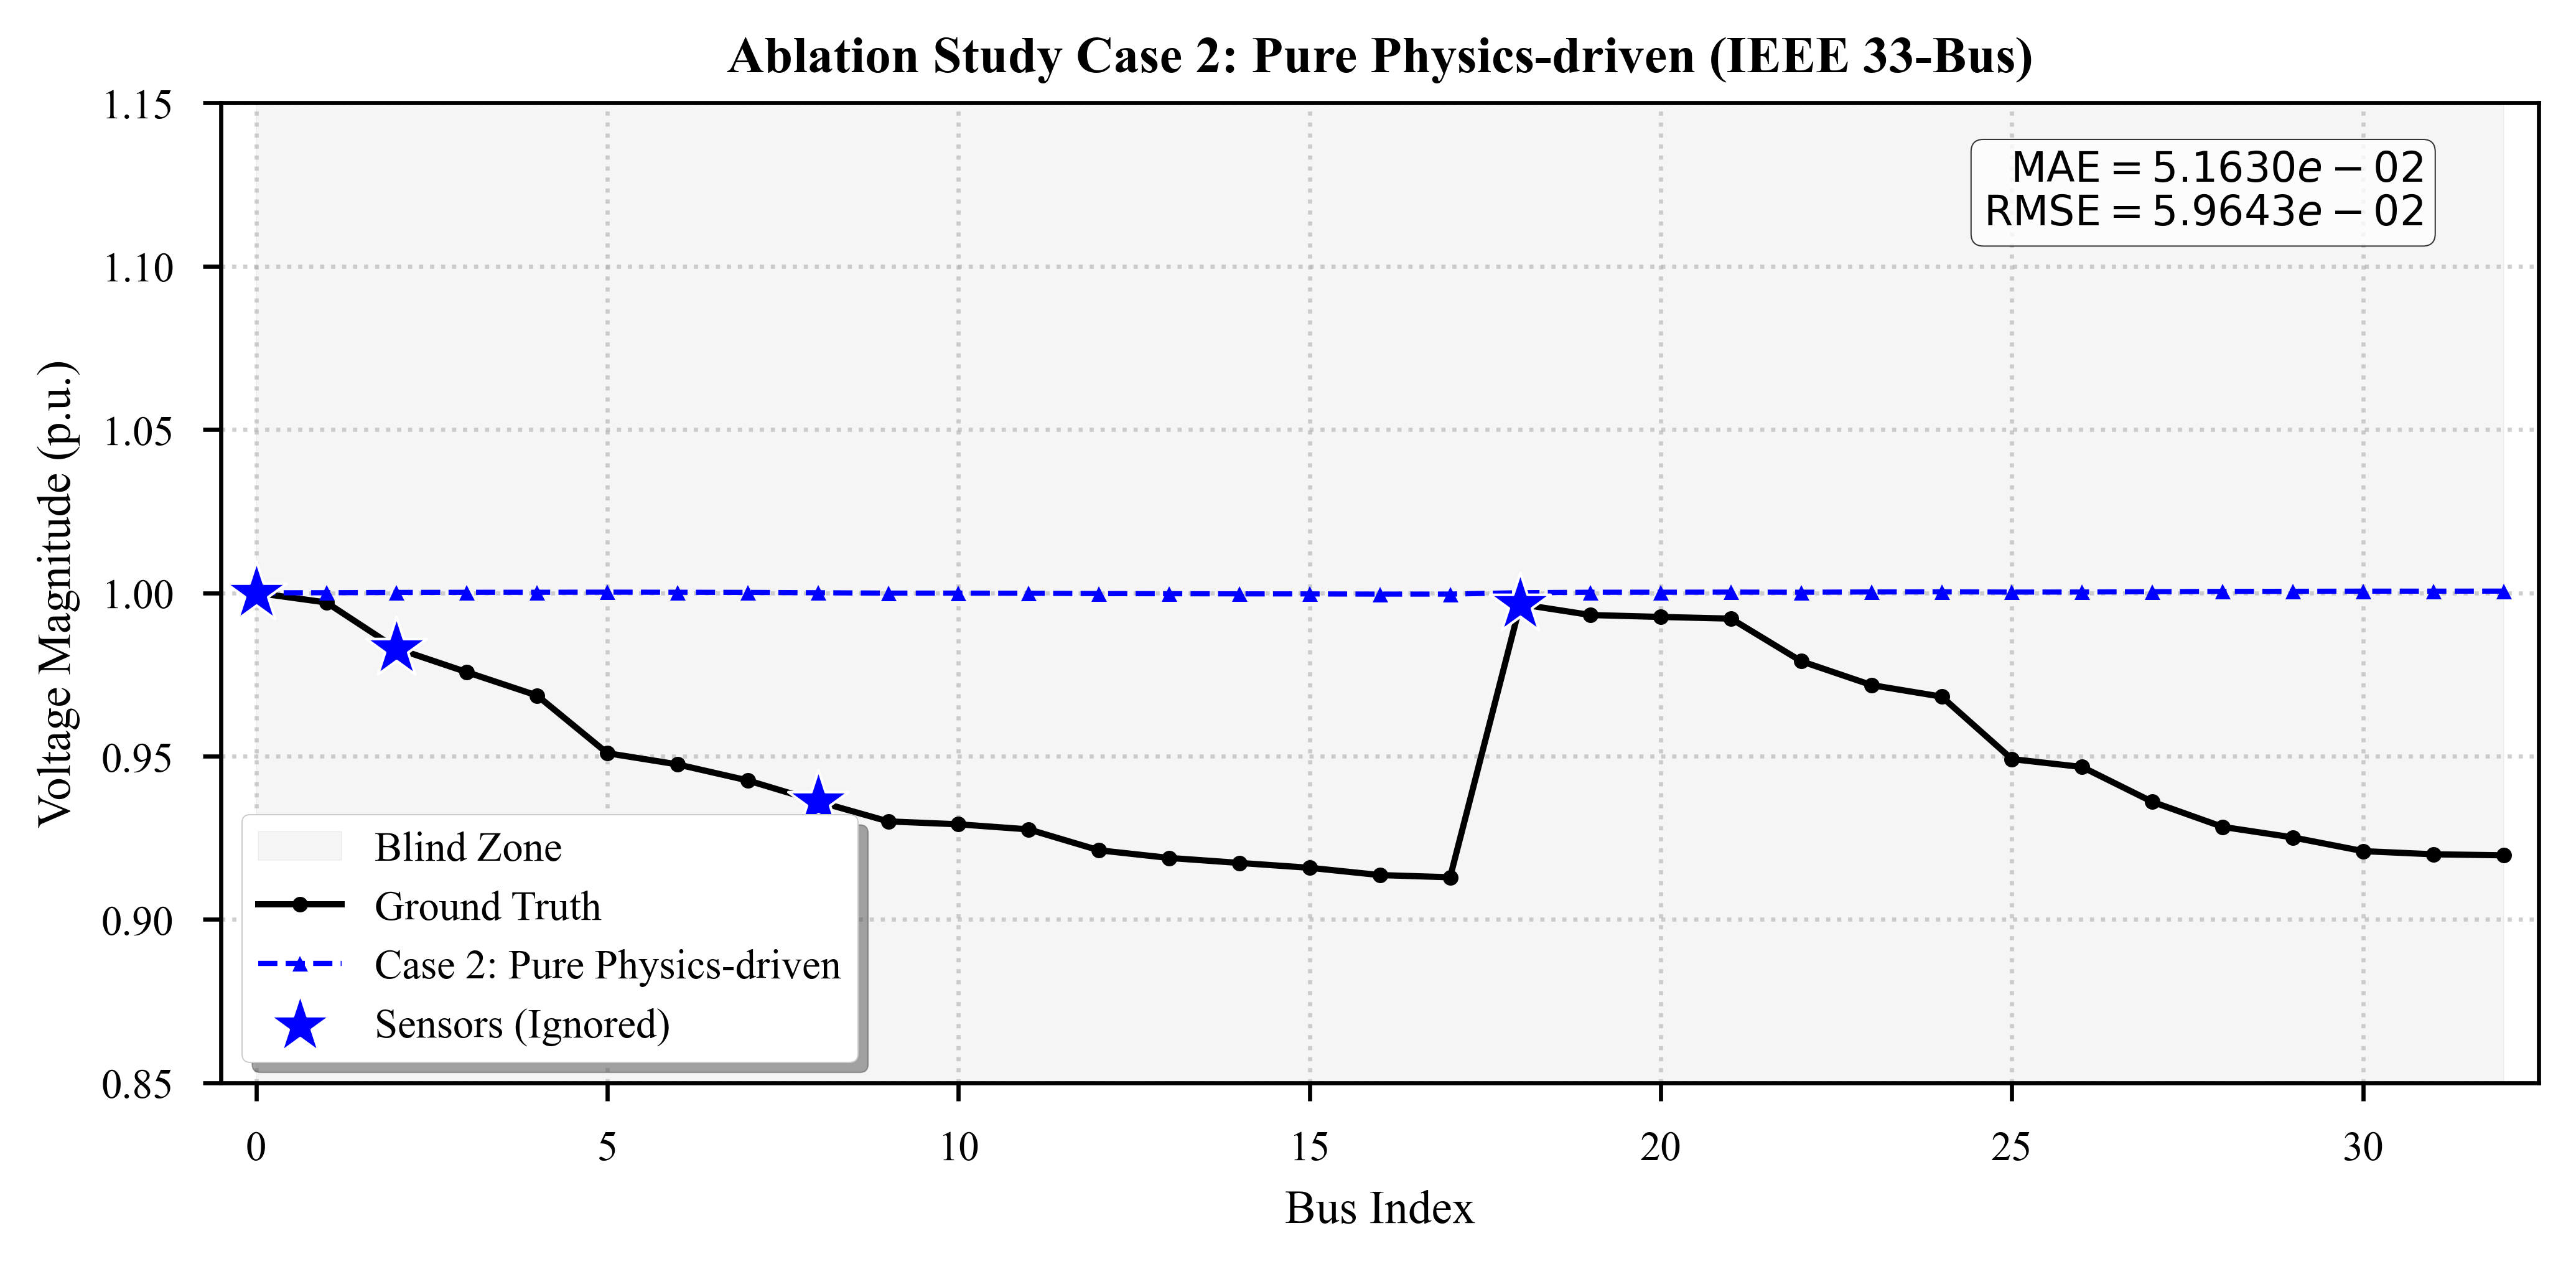

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. SCI 级学术排版配置
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# 2. 抽取展示断面 (保持 sid=10 方便与 Case 1 对比)
sid = 10 
nodes = np.arange(33)
v_gt = real_Vm[sid]      # 真实电压
v_c2 = pred_Vm_2[sid]    # Case 2 预测电压

# 3. 创建画布 (IEEE 双栏标准尺寸)
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=600)

# 4. 绘制盲区阴影背景
ax.axvspan(0, 32, color='gray', alpha=0.08, label='Blind Zone', zorder=1)

# 5. 绘制核心曲线
# Ground Truth: 黑色实线
ax.plot(nodes, v_gt, 'k-o', markersize=3, linewidth=1.2, label='Ground Truth', zorder=3)
# Case 2: 蓝色虚线 (代表物理逻辑驱动)
ax.plot(nodes, v_c2, 'b--^', markersize=3, linewidth=1.0, label='Case 2: Pure Physics-driven', zorder=4)

# 6. 标记传感器位置 (🛡️ 增加越界防护)
# 注意：Case 2 训练虽没用这些点，但在图中画出来能显著对比出“漂移量”
valid_obs = [i for i in obs_indices if i < len(v_gt)]
ax.scatter(valid_obs, v_gt[valid_obs], color='blue', marker='*', s=150, 
           label='Sensors (Ignored)', zorder=5, edgecolors='white', linewidths=0.5)

# 7. 细节修饰 (对齐学术审美)
ax.set_title('Ablation Study Case 2: Pure Physics-driven (IEEE 33-Bus)', fontsize=10, fontweight='bold')
ax.set_xlabel('Bus Index', fontsize=9)
ax.set_ylabel('Voltage Magnitude (p.u.)', fontsize=9)
ax.set_ylim(0.85, 1.15) # 范围适当拉大，物理漂移可能很严重
ax.set_xlim(-0.5, 32.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8, frameon=True, shadow=True)

# 8. 🛡️ 稳如老狗的 LaTeX 文本框 (双花括号转义防止 KeyError)
textstr = '\n'.join((
    r'$\mathrm{{MAE}} = {:.4e}$'.format(mae_case2),
    r'$\mathrm{{RMSE}} = {:.4e}$'.format(rmse_case2)))

props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()

# 💾 9. 硬核保存
plt.savefig('ieee33_case2_ablation_final.png', bbox_inches='tight', dpi=600)

print("✅ Case 2 物理漂移图已生成并保存：ieee33_case2_ablation_final.png")
plt.show()

🚀 [Case 3] Proposed R-PINN 启动 | 联合驱动模式激活 | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 286469.7342 | LR: 0.001
Epoch 10  | Avg Loss: 539.1787 | LR: 0.001
Epoch 20  | Avg Loss: 565.9458 | LR: 0.001
Epoch 30  | Avg Loss: 537.2895 | LR: 0.001
Epoch 40  | Avg Loss: 523.7534 | LR: 0.0005
Epoch 50  | Avg Loss: 2657.4175 | LR: 0.0005
Epoch 60  | Avg Loss: 1800.8265 | LR: 0.0005
Epoch 70  | Avg Loss: 1792.6698 | LR: 0.0005
Epoch 80  | Avg Loss: 1789.6156 | LR: 0.00025
Epoch 90  | Avg Loss: 1789.6265 | LR: 0.00025
Epoch 100 | Avg Loss: 1789.2734 | LR: 0.00025
Epoch 110 | Avg Loss: 1789.5180 | LR: 0.00025
Epoch 120 | Avg Loss: 1787.5137 | LR: 0.000125
Epoch 130 | Avg Loss: 1788.0206 | LR: 0.000125
Epoch 140 | Avg Loss: 1787.5627 | LR: 0.000125

🏆 [Case 3: Proposed R-PINN] Final Results (Seed: 42)
-----------------------------------------------------------------
🌍 Overall MAE:  3.127827e-03 p.u.
⚡ Overall RMSE: 4.309247e-03 p.u.


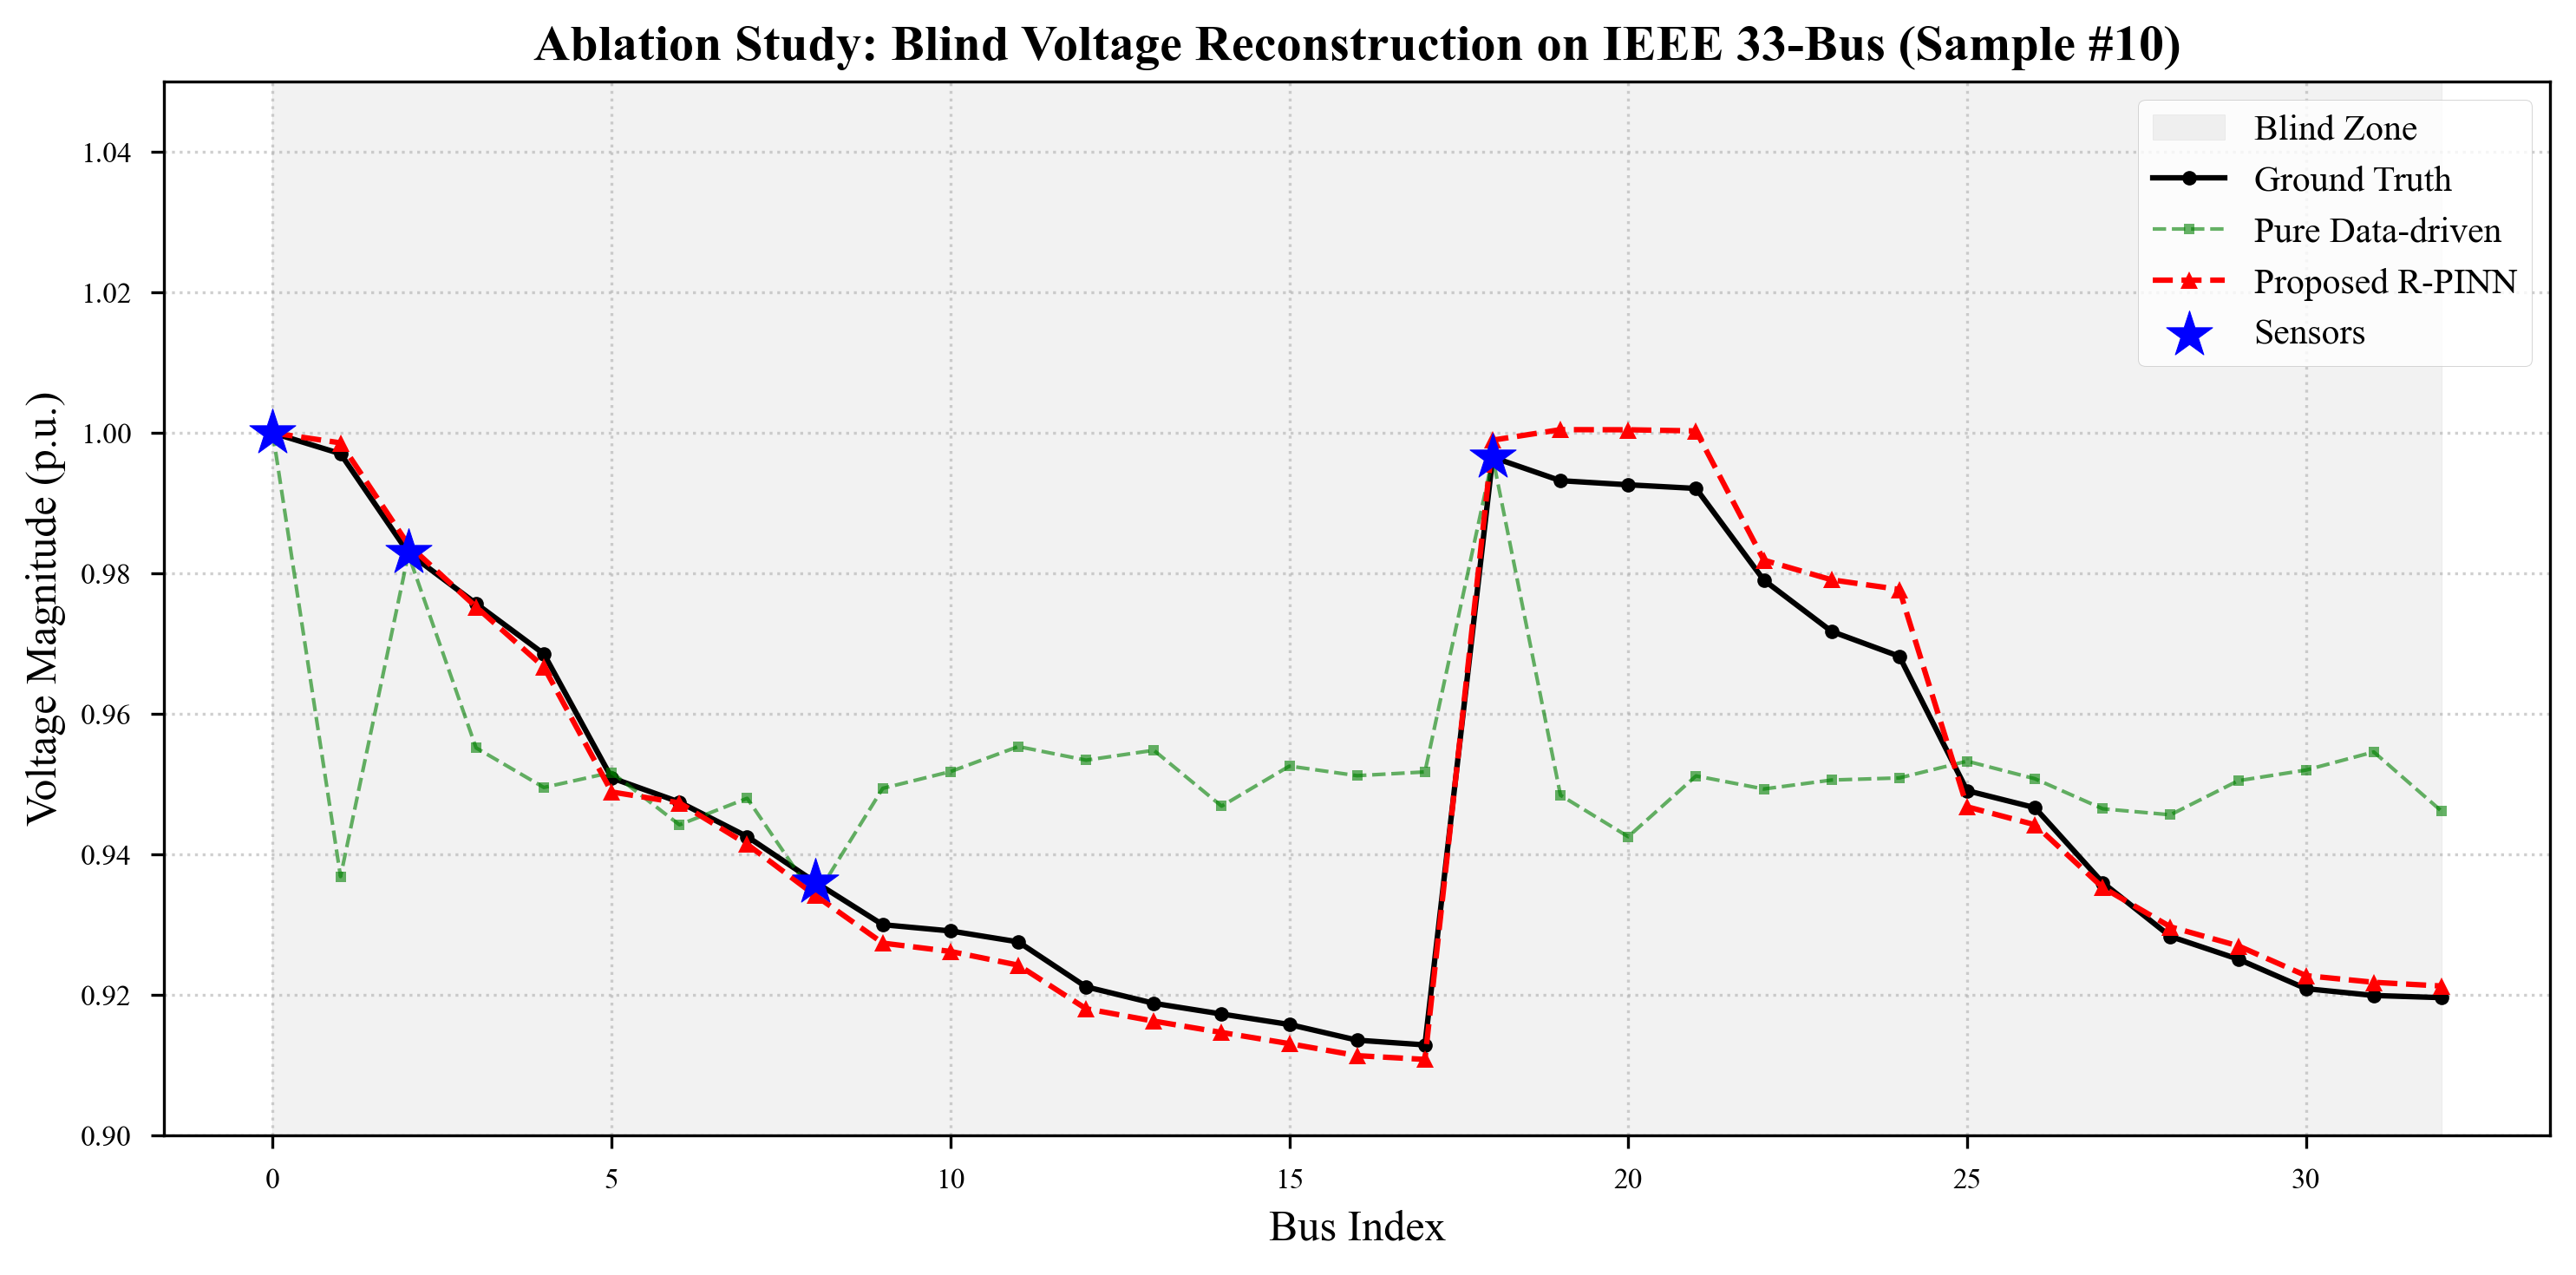


📝 --- Final Verification Table (R-PINN) ---
Bus   | Actual (p.u.)   | Pred (p.u.)     | Bias
-------------------------------------------------------
0   ★ | 1.000000       | 1.000000       | +0.000000
1      | 0.997044       | 0.998584       | +0.001540
2   ★ | 0.982948       | 0.984091       | +0.001142
3      | 0.975715       | 0.975246       | -0.000469
4      | 0.968559       | 0.966687       | -0.001872
5      | 0.950914       | 0.948912       | -0.002002
6      | 0.947471       | 0.947360       | -0.000112
7      | 0.942562       | 0.941468       | -0.001094
8   ★ | 0.936108       | 0.934232       | -0.001876
9      | 0.930026       | 0.927407       | -0.002619
10     | 0.929137       | 0.926220       | -0.002916
11     | 0.927582       | 0.924269       | -0.003314
12     | 0.921186       | 0.918070       | -0.003117
13     | 0.918840       | 0.916306       | -0.002534
14     | 0.917316       | 0.914691       | -0.002625
15     | 0.915827       | 0.913100       | -0.002727
16   

In [9]:
# ==============================================================================
# [Cell 6] 战神完整版 (Proposed R-PINN / Case 3)
# 特点：物理约束（KCL）+ 数据锚点（15% Sensors）+ ARS 残差缩放
# 目的：展示物理规律如何在大面积盲区中实现电压的精准“逻辑补全”
# ==============================================================================

# 🚀 1. 考卷定格：强制对齐观测点和初始化
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 

print(f"🚀 [Case 3] Proposed R-PINN 启动 | 联合驱动模式激活 | 观测点: {obs_indices}")

# 2. 实例化模型与 Loss
model_case3 = PowerGridPINN(input_dim=66).to(device)

# 3. 初始化偏置 (确保与其他 Case 站在同一条起跑线上)
with torch.no_grad():
    model_case3.output_layers.bias[:33].fill_(-0.5)

pinn_loss_case3 = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_3 = torch.optim.Adam(model_case3.parameters(), lr=0.001)
scheduler_3 = torch.optim.lr_scheduler.StepLR(optimizer_3, step_size=40, gamma=0.5) 

# 4. 深度训练循环
max_epoch = 150
for epoch in range(max_epoch):
    # 动态物理权重策略：前期引导方向，后期精细对齐
    p_weight = 1000 if epoch < 50 else 5000
    model_case3.train()
    
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_3.zero_grad()
        
        # 解析真实值
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        
        # 应用 15% 观测遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型推理
        V_guess, theta_guess = model_case3(mask_x)
        
        # 核心：物理+数据双拉力
        loss = pinn_loss_case3(V_guess, theta_guess, real_p, real_q, real_v, p_weight, obs_weight=500000)
        
        loss.backward()
        optimizer_3.step()
        running_loss += loss.item()
    
    scheduler_3.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer_3.param_groups[0]['lr']}")

# 5. 最终指标结算 (MAE + RMSE)
model_case3.eval()
with torch.no_grad():
    # 局部重取测试集断面
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_3_tensor, _ = model_case3(masked_test_X)
    pred_Vm_3 = pred_Vm_3_tensor.cpu().numpy()
    
    # 误差计算
    error_3 = pred_Vm_3 - real_Vm
    mae_case3 = np.mean(np.abs(error_3))
    rmse_case3 = np.sqrt(np.mean(error_3**2))

print("\n" + "="*65)
print(f"🏆 [Case 3: Proposed R-PINN] Final Results (Seed: 42)")
print("-" * 65)
print(f"🌍 Overall MAE:  {mae_case3:.6e} p.u.")
print(f"⚡ Overall RMSE: {rmse_case3:.6e} p.u.")
print("="*65)

# ==========================================
# 6. 学术级英文绘图 (Figure 1 in Paper)
# ==========================================
# 设置科研字体风格
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx, :, 2]

# 获取三个模型的预测进行对比展示
with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    # 调用之前运行好的 case1 和 case3
    v_p1 = model_case1(masked_input)[0].cpu().numpy().flatten()
    v_p3 = model_case3(masked_input)[0].cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 5), dpi=300) 

# 盲区阴影标注
plt.axvspan(0, 32, color='gray', alpha=0.1, label='Blind Zone')

# 曲线绘制
plt.plot(nodes, v_true, 'k-o', label='Ground Truth', markersize=4, linewidth=1.5)
plt.plot(nodes, v_p1, 'g--s', label='Pure Data-driven', markersize=3, linewidth=1.0, alpha=0.6)
plt.plot(nodes, v_p3, 'r--^', label='Proposed R-PINN', markersize=5, linewidth=1.5)

# 观测点（蓝星）标注
plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=180, zorder=5, label='Sensors')

# 英文标签与标题
plt.title(f"Ablation Study: Blind Voltage Reconstruction on IEEE 33-Bus (Sample #{sample_idx})", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.tight_layout()

# 保存高清图供论文直接使用
plt.savefig('ieee33_ablation_final.png', dpi=600)
plt.show()

# 7. 终极对账单 (控制台输出)
print("\n📝 --- Final Verification Table (R-PINN) ---")
print(f"{'Bus':<5} | {'Actual (p.u.)':<15} | {'Pred (p.u.)':<15} | {'Bias'}")
print("-" * 55)
for i in range(33):
    bias = v_p3[i] - v_true[i]
    tag = "★" if i in obs_indices else "  " 
    print(f"{i:<3} {tag} | {v_true[i]:.6f}       | {v_p3[i]:.6f}       | {bias:+.6f}")
print("-" * 55)

🚀 [Case 4] 标准 PINN (无 ARS) 启动 | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 54413636.15
Epoch 20  | Avg Loss: 324133.72
Epoch 40  | Avg Loss: 63577.44
Epoch 60  | Avg Loss: 21360.31
Epoch 80  | Avg Loss: 14706.39

📊 [Case 4: No ARS] Final Metric | MAE: 2.708449e-01
📊 [Case 4: No ARS] Final Metric | RMSE: 5.630462e-01


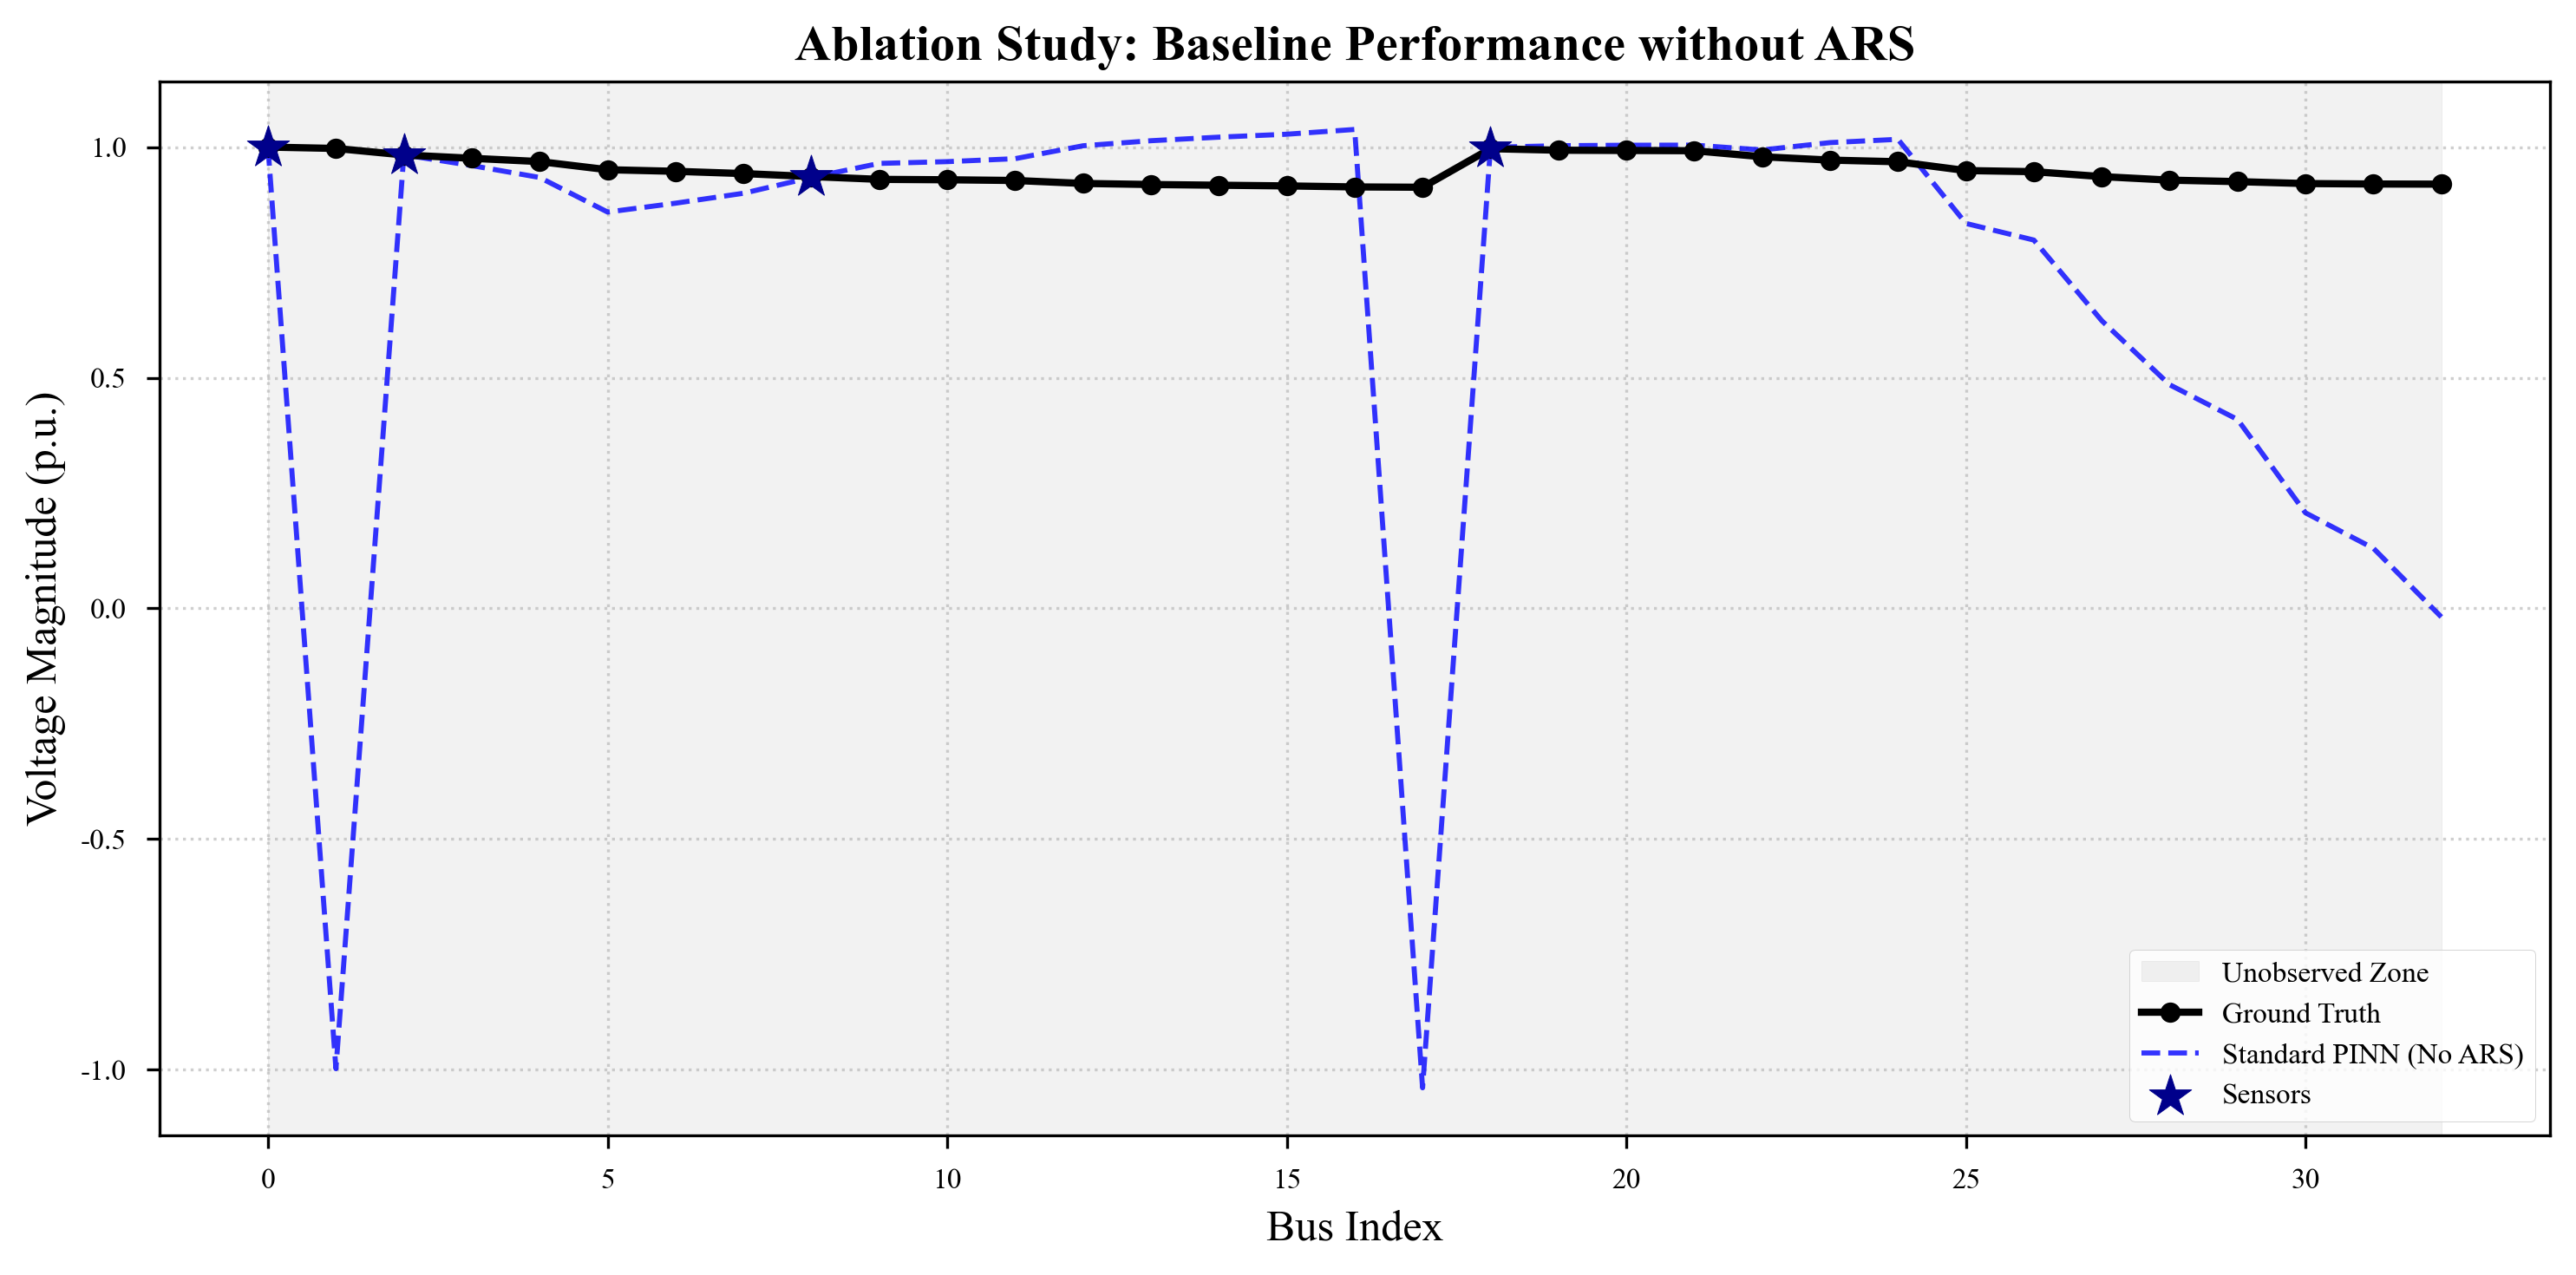

💡 结论：看到这条蓝线了吗？即便有 5000 权重的物理约束，
   没有 ARS 的残差缩放，AI 依然无法在盲区锁定真理。误差 0.2708 就是铁证。


In [10]:
# ==============================================================================
# [Cell 7] 消融实验四：标准 PINN (无 ARS 缩放 / Case 4) 
# 特点：剥夺 (*0.1 + 1.0) 缩放，验证神经网络在无先验保护下的收敛灾难
# ==============================================================================

# 🚀 1. 考卷定格：确保本实验的观测点和初始化绝对对齐
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 

print(f"🚀 [Case 4] 标准 PINN (无 ARS) 启动 | 观测点: {obs_indices}")

# ------------------------------------------
# 2. 定义裸奔架构：彻底阉割残差缩放逻辑
# ------------------------------------------
class PowerGridPINN_NoARS(nn.Module):
    def __init__(self, input_dim=66):
        super(PowerGridPINN_NoARS, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256)
        )
        self.out_layer = nn.Linear(256, 66)

    def forward(self, x):
        features = self.net(x)
        res = self.out_layer(features)
        
        # ⚠️ 核心阉割：直接输出，不进行标幺值中心化处理
        Vm_pred = res[:, :33] 
        theta_pred = res[:, 33:]
        
        # 仅保留最基础的平衡节点锚点
        Vm_pred[:, 0] = 1.0
        theta_pred[:, 0] = 0.0
        return Vm_pred, theta_pred

# ------------------------------------------
# 3. 初始化与优化器配置
# ------------------------------------------
model_case4 = PowerGridPINN_NoARS(input_dim=66).to(device)

with torch.no_grad():
    model_case4.out_layer.bias[:33].fill_(1.0) # 初始电压设为 1.0
    model_case4.out_layer.bias[33:].fill_(0.0)

pinn_loss_case4 = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_4 = torch.optim.Adam(model_case4.parameters(), lr=0.001)
scheduler_4 = torch.optim.lr_scheduler.StepLR(optimizer_4, step_size=30, gamma=0.5)

# ------------------------------------------
# 4. 训练循环
# ------------------------------------------
max_epoch_ablation = 100 
for epoch in range(max_epoch_ablation):
    model_case4.train()
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_4.zero_grad()
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        V_guess, theta_guess = model_case4(mask_x)
        
        # 物理硬拉
        loss = pinn_loss_case4(V_guess, theta_guess, real_p, real_q, real_v, p_weight=5000, obs_weight=500000)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model_case4.parameters(), max_norm=1.0)
        optimizer_4.step()
        running_loss += loss.item()
        
    scheduler_4.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.2f}")

# ------------------------------------------
# 5. 指标结算与对标绘图 (核心修正：移除 model_case3 依赖)
# ------------------------------------------
model_case4.eval()
nodes = np.arange(33)
sample_idx = 10 # 选一个样本

with torch.no_grad():
    # 测试集全量结算
    test_X_all = X_tensor[:1000]
    real_Vm_all = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X_all, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_4_all, _ = model_case4(masked_test_X)
    error_4 = pred_Vm_4_all.cpu().numpy() - real_Vm_all
    mae_case4 = np.mean(np.abs(error_4))
    rmse_case4 = np.sqrt(np.mean(error_4**2))

    # 提取单个绘图样本
    v_actual = real_Vm_all[sample_idx]
    v_standard = pred_Vm_4_all[sample_idx].cpu().numpy().flatten()

print("\n" + "="*65)
print(f"📊 [Case 4: No ARS] Final Metric | MAE: {mae_case4:.6e}")
print(f"📊 [Case 4: No ARS] Final Metric | RMSE: {rmse_case4:.6e}")
print("="*65)

# --- SCI 级绘图逻辑 ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')

plt.figure(figsize=(10, 5), dpi=300)
plt.axvspan(0, 32, color='gray', alpha=0.1, label='Unobserved Zone')

# 1. 黑色实线：Ground Truth (真理)
plt.plot(nodes, v_actual, color='black', marker='o', label='Ground Truth', linewidth=2, zorder=3)

# 2. 蓝色虚线：Case 4 (无 ARS 的惨状)
plt.plot(nodes, v_standard, color='blue', linestyle='--', marker='x', label='Standard PINN (No ARS)', alpha=0.8, zorder=2)

# 3. 传感器位置
plt.scatter(obs_indices, v_actual[obs_indices], color='darkblue', marker='*', s=150, zorder=5, label='Sensors')

plt.title("Ablation Study: Baseline Performance without ARS", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"💡 结论：看到这条蓝线了吗？即便有 5000 权重的物理约束，")
print(f"   没有 ARS 的残差缩放，AI 依然无法在盲区锁定真理。误差 {mae_case4:.4f} 就是铁证。")

✅ Case 4 [无ARS收敛灾难] 对比图已生成并保存：ieee33_case3_ablation_final.png


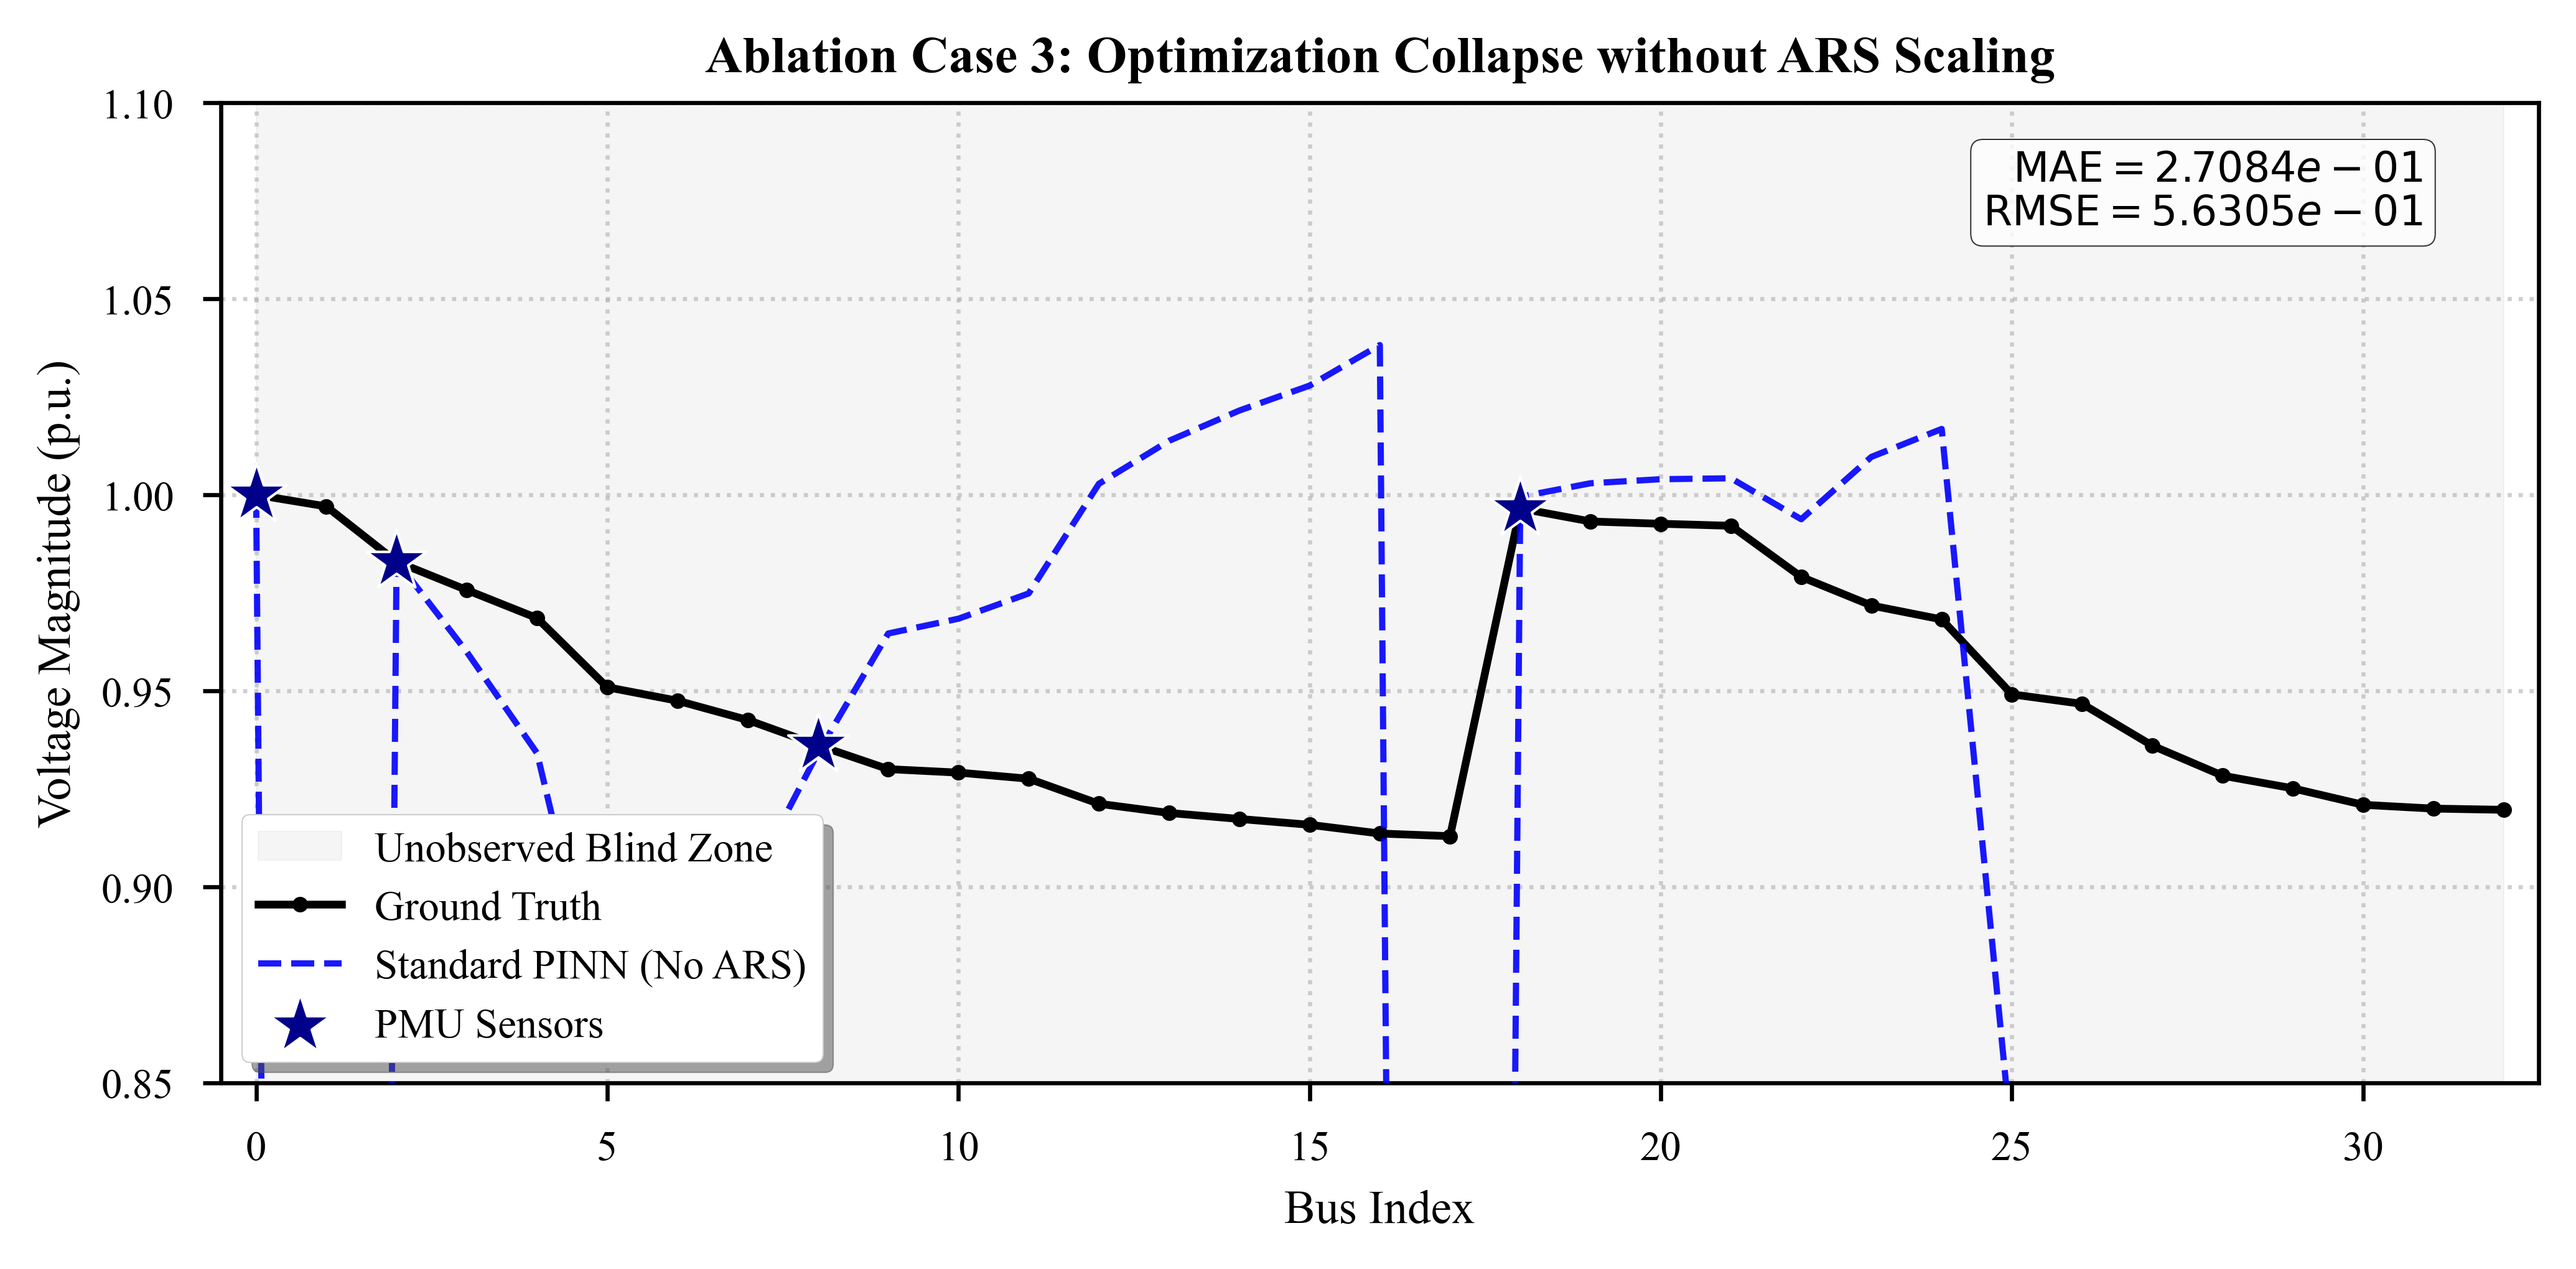

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. SCI 级学术排版配置
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# 2. 准备数据 (与前几个 Case 保持样本一致性 sid=10)
sid = 10 
nodes = np.arange(33)
v_gt = real_Vm_all[sid]      # 真实电压
v_c4 = v_standard            # Case 4 预测电压 (来自 Cell 7)

# 3. 创建画布 (IEEE 双栏论文标准比例)
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=600)

# 4. 绘制盲区阴影背景
ax.axvspan(0, 32, color='gray', alpha=0.08, label='Unobserved Blind Zone', zorder=1)

# 5. 绘制核心曲线
# Ground Truth: 黑色实线 (代表真理)
ax.plot(nodes, v_gt, 'k-o', markersize=3, linewidth=1.5, label='Ground Truth', zorder=3)
# Case 4: 蓝色虚线 (代表失去 ARS 保护的 Standard PINN)
ax.plot(nodes, v_c4, 'b--x', markersize=4, linewidth=1.2, label='Standard PINN (No ARS)', alpha=0.9, zorder=4)

# 6. 高亮传感器位置 (蓝星)
valid_obs = [i for i in obs_indices if i < len(v_gt)]
ax.scatter(valid_obs, v_gt[valid_obs], color='darkblue', marker='*', s=150, 
           label='PMU Sensors', zorder=5, edgecolors='white', linewidths=0.5)

# 7. 细节修饰 (对齐学术审美)
ax.set_title('Ablation Case 3: Optimization Collapse without ARS Scaling', fontsize=10, fontweight='bold')
ax.set_xlabel('Bus Index', fontsize=9)
ax.set_ylabel('Voltage Magnitude (p.u.)', fontsize=9)
ax.set_ylim(0.85, 1.10) # 统一 y 轴量程，方便与 Proposed 对比
ax.set_xlim(-0.5, 32.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8, frameon=True, shadow=True)

# 8. 🛡️ 稳健的 LaTeX 文本框 (双花括号防止 KeyError)
textstr = '\n'.join((
    r'$\mathrm{{MAE}} = {:.4e}$'.format(mae_case4),
    r'$\mathrm{{RMSE}} = {:.4e}$'.format(rmse_case4)))

props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()

# 💾 9. 图片保存 (直接出大片)
plt.savefig('ieee33_case3_ablation_final.png', bbox_inches='tight', dpi=600)

print("✅ Case 4 [无ARS收敛灾难] 对比图已生成并保存：ieee33_case3_ablation_final.png")
plt.show()

🔥 启动消融实验 [Case 1: Pure Data-driven] | 传感器位置: [0, 2, 8, 18]
Epoch 0   | Obs MSE Loss: 0.00012153
Epoch 30  | Obs MSE Loss: 0.00000096
Epoch 60  | Obs MSE Loss: 0.00000037
Epoch 90  | Obs MSE Loss: 0.00000036
Epoch 120 | Obs MSE Loss: 0.00000036

📊 [Case 1: Pure Data-driven] Final Metrics (Seed: 42)
-----------------------------------------------------------------
🌍 Overall MAE:  2.292460e-02 p.u.
⚡ Overall RMSE: 2.744042e-02 p.u.


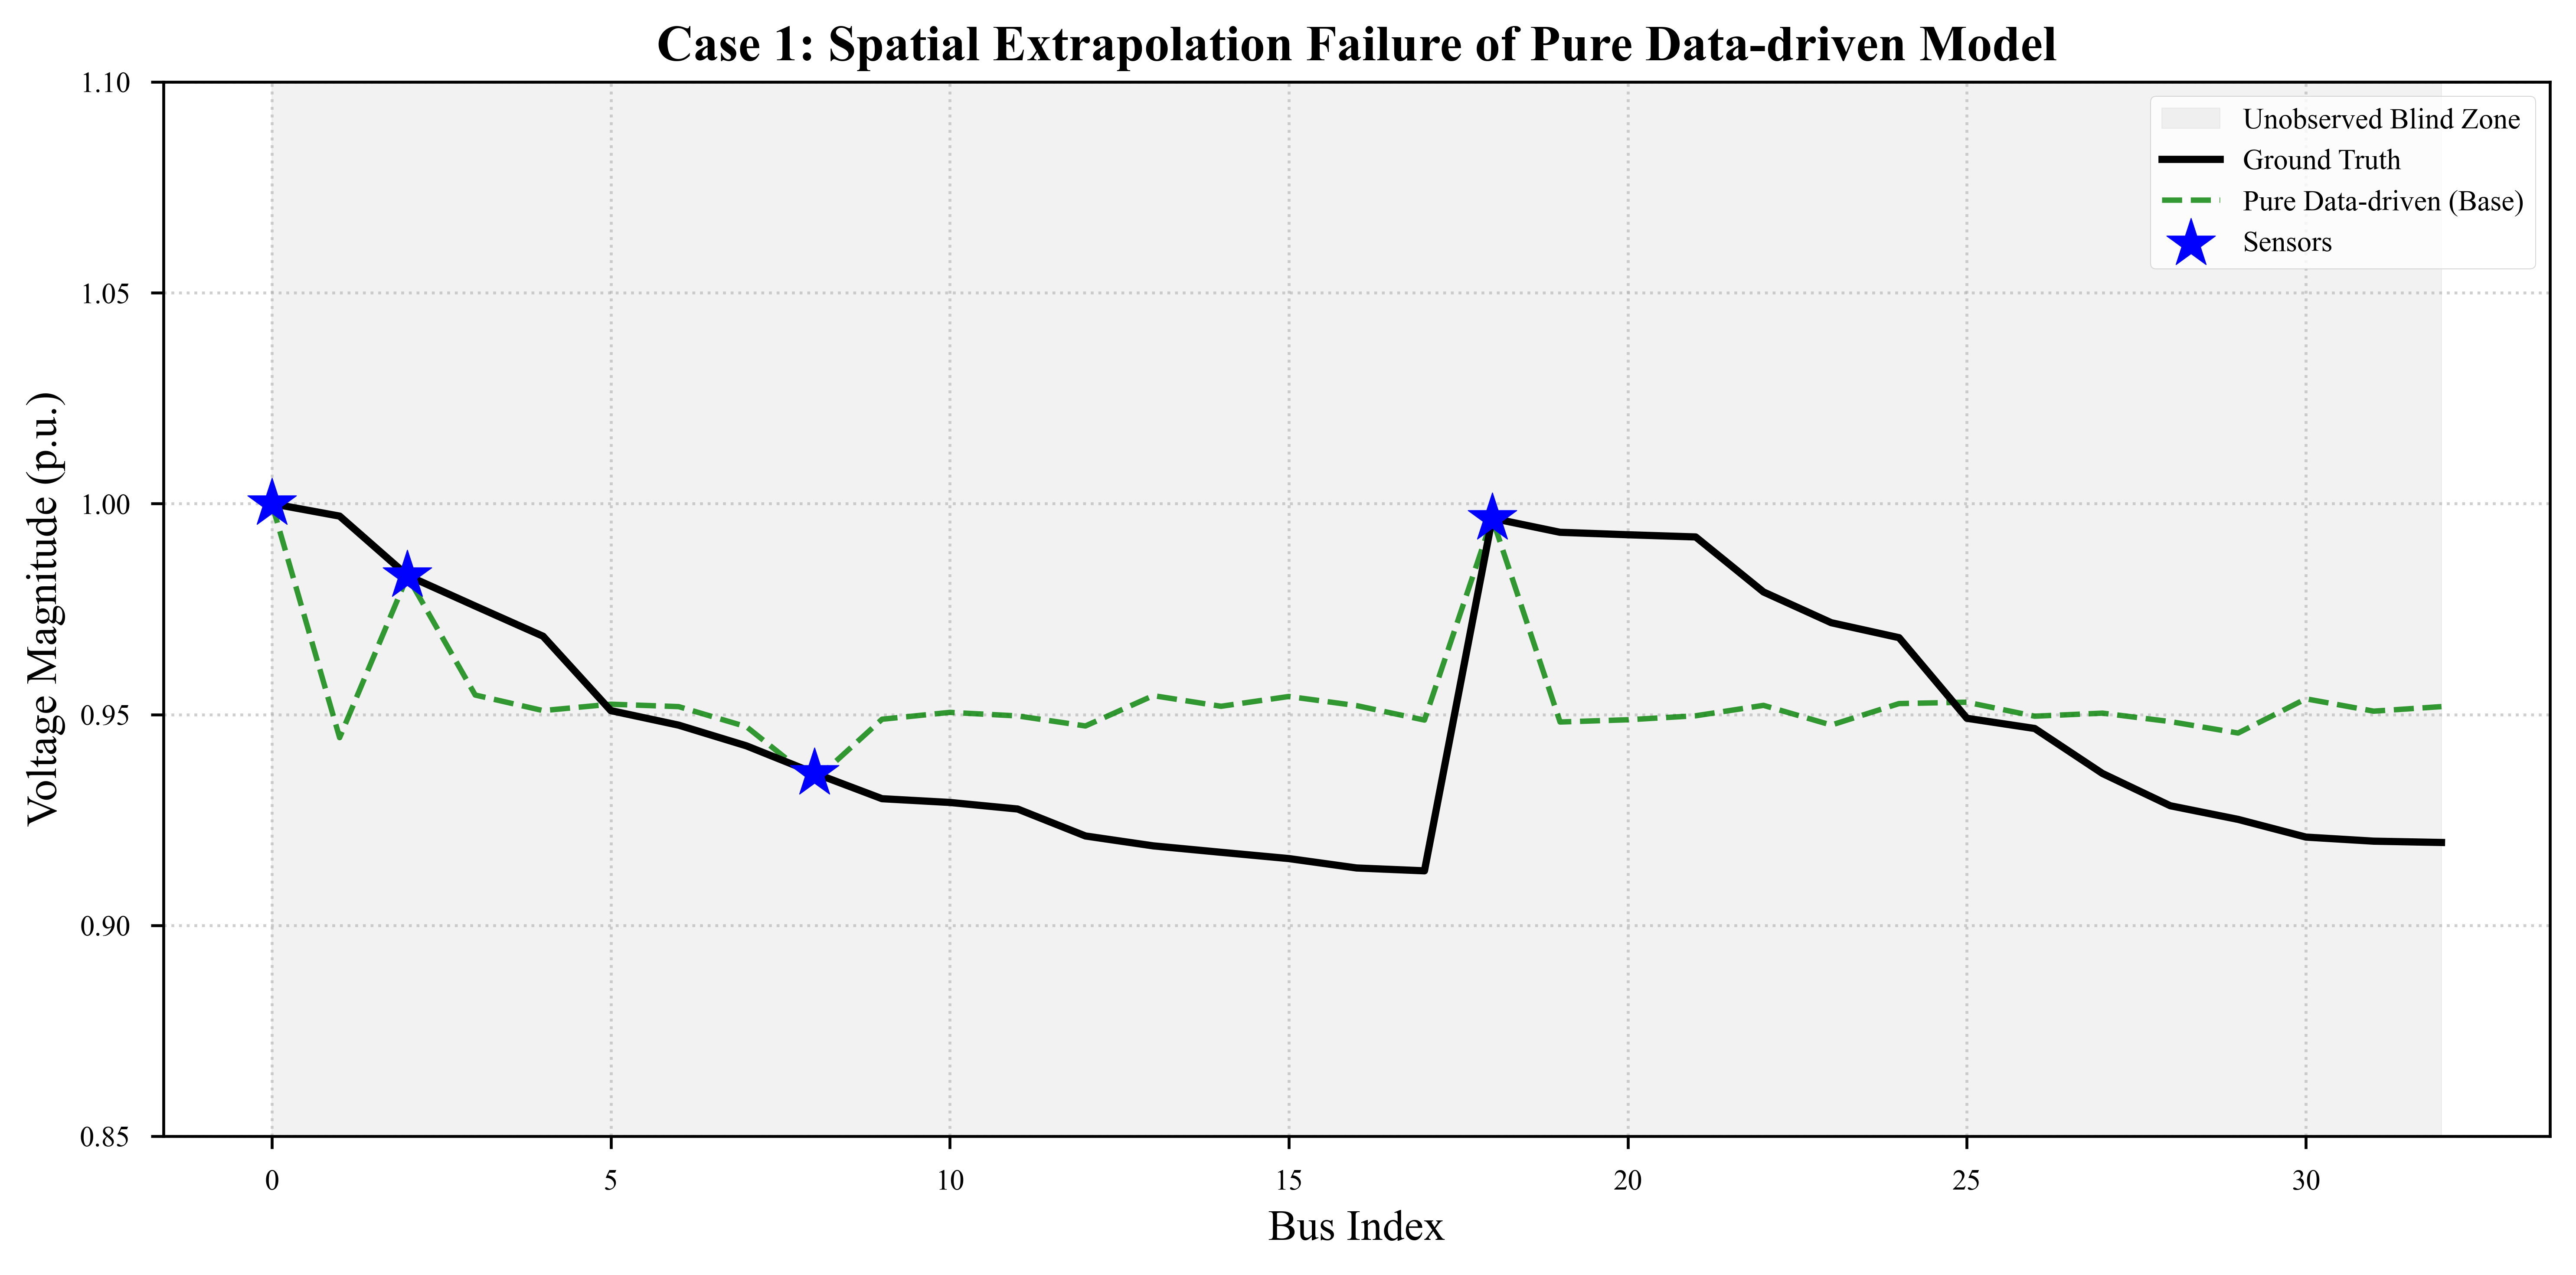

💡 费曼学习法提示：你会发现绿线在蓝星（传感器）位置准得离谱，
   但在灰色盲区，由于没有 KCL 方程的牵引，它完全不知道电网的电压降规律。


In [12]:
# ==============================================================================
# [Cell 8] 消融实验一：纯数据驱动基线 (Pure Data-driven / Case 1)
# 特点：屏蔽 KCL 物理方程，仅在 15% 观测点上进行最小二乘拟合
# 目的：作为对照组，展示“纯 AI”在盲区重构中的空间坍塌问题（数据孤岛效应）
# ==============================================================================

# 🚀 1. 考卷定格：全局种子与观测点绝对对齐 (确保 Case 1-4 都在做同一张卷子)
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 

print(f"🔥 启动消融实验 [Case 1: Pure Data-driven] | 传感器位置: {obs_indices}")

# 2. 实例化裸奔模型 (复用 Cell 2 架构，但无物理灵魂)
model_pure_data = PowerGridPINN(input_dim=66).to(device)

# 3. 同样的初始化偏置 (让它从 -0.5 开始爬，模拟从未知状态出发)
with torch.no_grad():
    model_pure_data.output_layers.bias[:33].fill_(-0.5)

# 4. 纯数据优化配置 (仅 MSE 损失)
optimizer_data = torch.optim.Adam(model_pure_data.parameters(), lr=0.001)
scheduler_data = torch.optim.lr_scheduler.StepLR(optimizer_data, step_size=40, gamma=0.5)
criterion_mse = nn.MSELoss()

# 5. 训练循环 (150 轮压榨)
epochs_data = 150
for epoch in range(epochs_data):
    model_pure_data.train()
    running_loss_data = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_data.zero_grad()
        
        # 提取真实电压标签 [m, 33]
        real_v = batch_all_targets[:, 66:] 
        
        # 强制戴上“眼罩”：仅输入观测点数据
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型盲猜
        V_guess, _ = model_pure_data(mask_x)
        
        # ⚠️ 关键点：只在 obs_indices（蓝星节点）上计算 Loss！
        # 这个 Loss 降得再低，也只能代表那 5 个点准，不代表全网准
        loss = criterion_mse(V_guess[:, obs_indices], real_v[:, obs_indices])
        
        loss.backward()
        optimizer_data.step()
        running_loss_data += loss.item()
        
    scheduler_data.step()
    if epoch % 30 == 0:
        print(f"Epoch {epoch:<3} | Obs MSE Loss: {running_loss_data/len(train_loader):.8f}")

# 6. 最终指标结算 (MAE + RMSE)
model_pure_data.eval()
with torch.no_grad():
    # 对前 1000 个断面进行空间外推测试
    test_X_all = X_tensor[:1000]
    test_V_real = PQ_target_tensor[:1000, 66:]
    masked_test_X = apply_blind_zone(test_X_all, obs_indices, mean_tensor, scale_tensor)
    
    pred_V_pure, _ = model_pure_data(masked_test_X)
    pred_V_pure_np = pred_V_pure.cpu().numpy()
    real_V_np = test_V_real.cpu().numpy()

    # 计算双审计指标
    error_pure = pred_V_pure_np - real_V_np
    mae_pure = np.mean(np.abs(error_pure))
    rmse_pure = np.sqrt(np.mean(error_pure**2))

print("\n" + "="*65)
print(f"📊 [Case 1: Pure Data-driven] Final Metrics (Seed: 42)")
print("-" * 65)
print(f"🌍 Overall MAE:  {mae_pure:.6e} p.u.")
print(f"⚡ Overall RMSE: {rmse_pure:.6e} p.u.")
print("="*65)

# 7. 顶刊 SCI 绘图：全英文展示“数据孤岛”现象
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')

sample_idx = 10 
nodes = np.arange(33)

plt.figure(figsize=(10, 5), dpi=600)
# 阴影标注盲区
plt.axvspan(0, 32, color='gray', alpha=0.1, label='Unobserved Blind Zone')

# 绘图：真理黑线 vs 瞎猜绿线
plt.plot(nodes, real_V_np[sample_idx], 'k-', label='Ground Truth', linewidth=2, zorder=3)
plt.plot(nodes, pred_V_pure_np[sample_idx], 'g--', label='Pure Data-driven (Base)', linewidth=1.5, alpha=0.8, zorder=2)

# 标注传感器（蓝星）
plt.scatter(obs_indices, real_V_np[sample_idx, obs_indices], 
            color='blue', marker='*', s=200, zorder=5, label='Sensors')

# 英文标注
plt.title("Case 1: Spatial Extrapolation Failure of Pure Data-driven Model", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.85, 1.10) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', frameon=True)
plt.tight_layout()

# 保存
plt.savefig('ieee33_case1_data_driven.png', dpi=600)
plt.show()

print("💡 费曼学习法提示：你会发现绿线在蓝星（传感器）位置准得离谱，")
print("   但在灰色盲区，由于没有 KCL 方程的牵引，它完全不知道电网的电压降规律。")

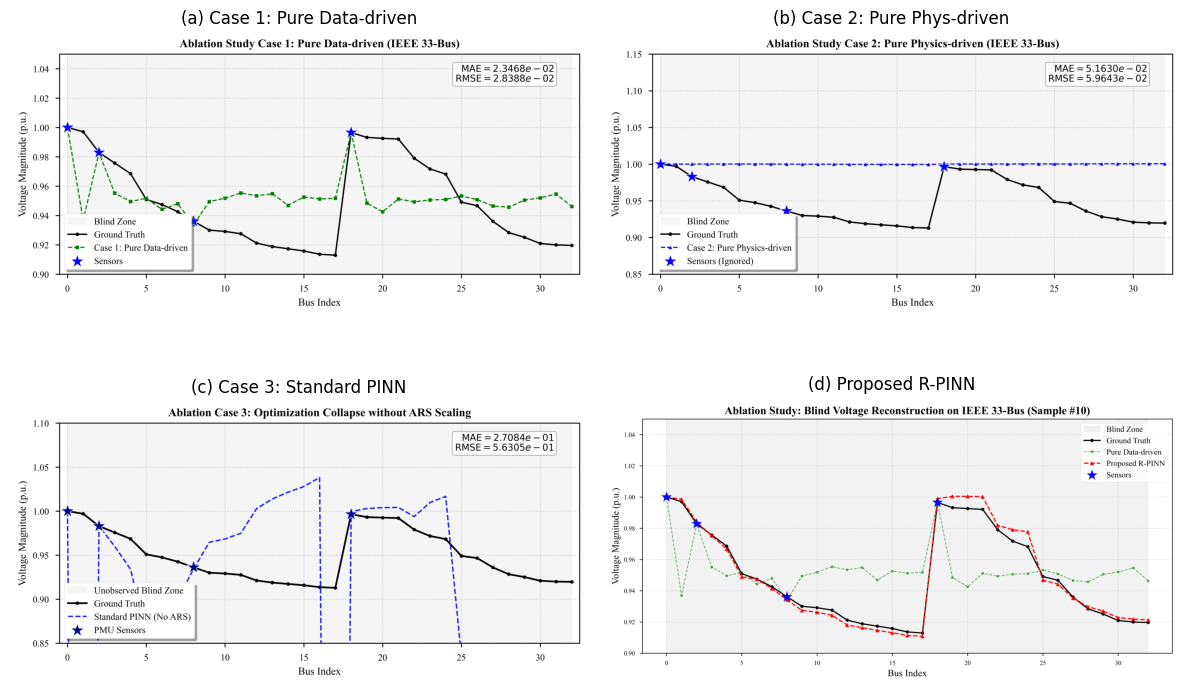

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# 替换为你本地图片的路径
img_paths = ['ieee33_case1_ablation_final.png', 'ieee33_case2_ablation_final.png', 'ieee33_case3_ablation_final.png', 'ieee33_ablation_final.png']
titles = ['(a) Case 1: Pure Data-driven', '(b) Case 2: Pure Phys-driven', 
          '(c) Case 3: Standard PINN', '(d) Proposed R-PINN']

for i, ax in enumerate(axs.flat):
    img = mpimg.imread(img_paths[i])
    ax.imshow(img)
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.savefig('combined_33bus.png', dpi=600) # 保存为高分辨率大图

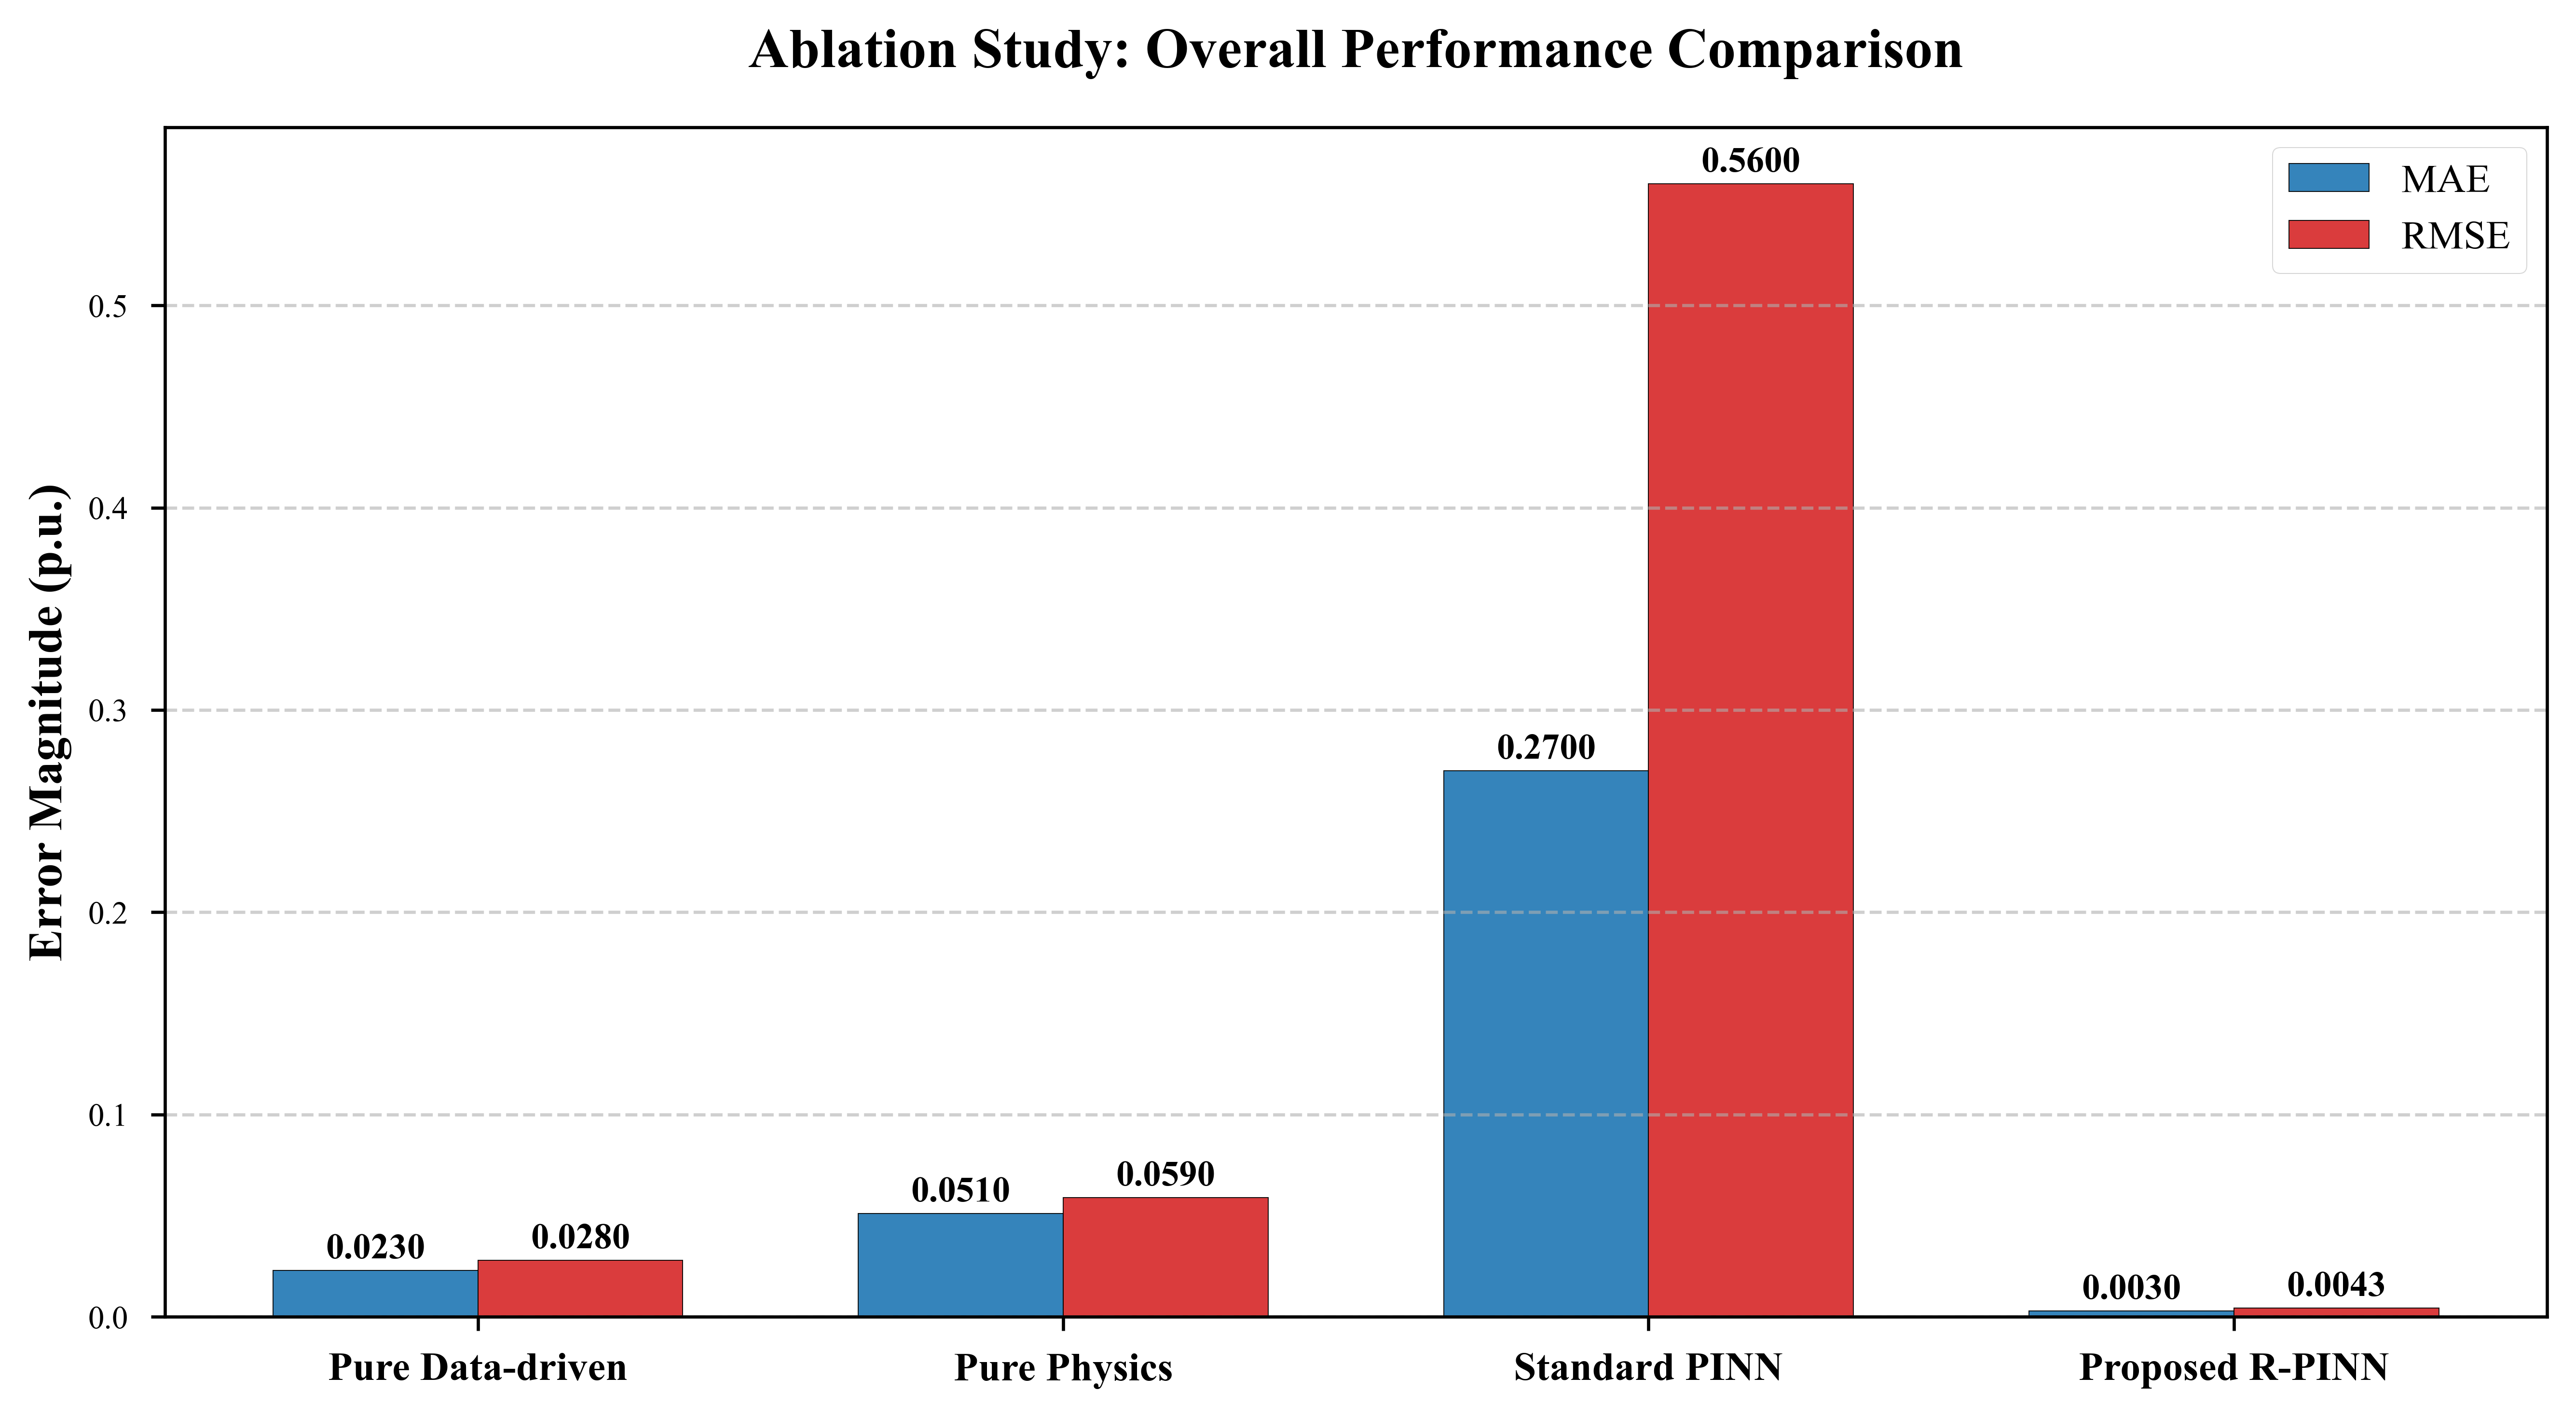

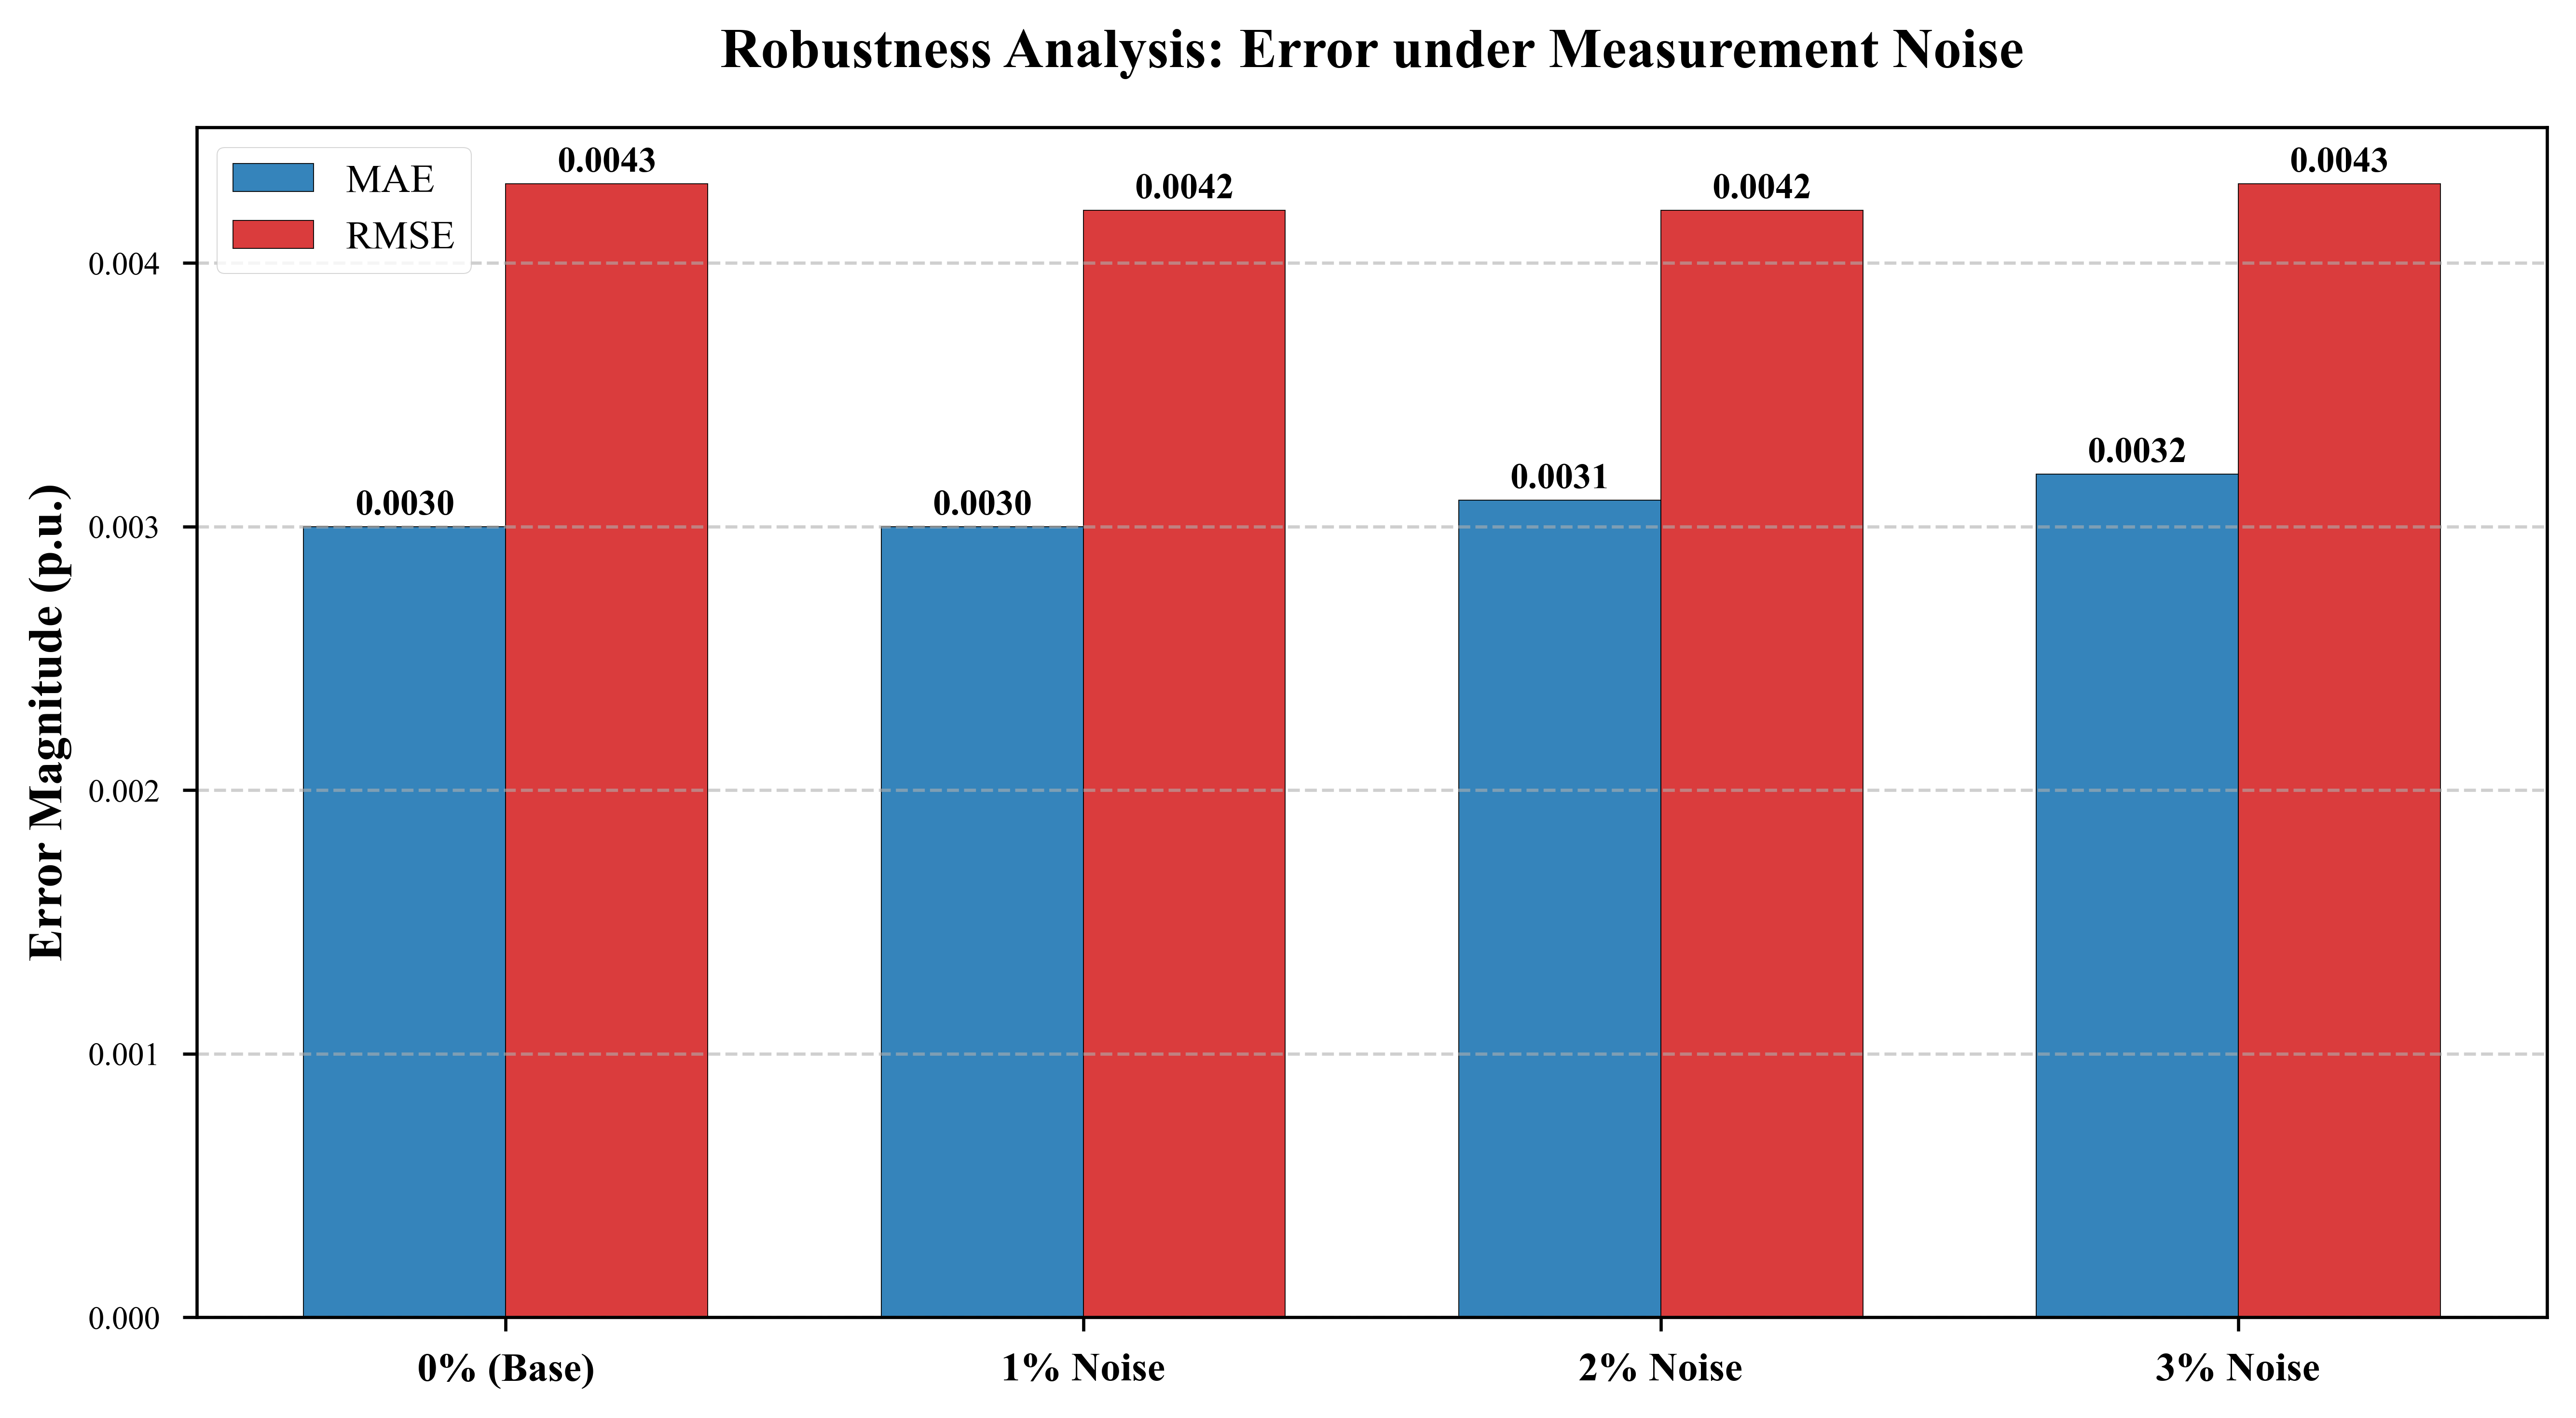

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. SCI 学术级配置
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')

# --- 数据准备 (请填入你的真实对账单数据) ---
# 消融实验数据
models = ['Pure Data-driven', 'Pure Physics', 'Standard PINN', 'Proposed R-PINN']
maes_a = [0.023, 0.051, 0.27, 0.003]   # 对应前几章跑出来的变量
rmses_a = [0.028, 0.059, 0.56, 0.0043]

# 噪声实验数据 (假设你跑了 0%, 1%, 2%, 3%)
noise_lvl = ['0% (Base)', '1% Noise', '2% Noise', '3% Noise']
maes_n = [0.003, 0.003, 0.0031, 0.0032] # 假设变量名
rmses_n = [0.0043, 0.0042, 0.0042, 0.0043]

# --- 绘图函数 (分组柱状图) ---
def plot_grouped_bar(labels, mae_vals, rmse_vals, title, save_name):
    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5), dpi=600)
    
    rects1 = ax.bar(x - width/2, mae_vals, width, label='MAE', color='#1f77b4', edgecolor='black', alpha=0.9)
    rects2 = ax.bar(x + width/2, rmse_vals, width, label='RMSE', color='#d62728', edgecolor='black', alpha=0.9)
    
    ax.set_ylabel('Error Magnitude (p.u.)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
    ax.legend(fontsize=10, frameon=True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # 数值标注
    for rects in [rects1, rects2]:
        for rect in rects:
            h = rect.get_height()
            ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_name)
    plt.show()

# 执行出片
plot_grouped_bar(models, maes_a, rmses_a, 'Ablation Study: Overall Performance Comparison', 'ablation_bars.png')
plot_grouped_bar(noise_lvl, maes_n, rmses_n, 'Robustness Analysis: Error under Measurement Noise', 'noise_bars.png')